## 1.1. <a id='toc1_1_'></a>[Import data](#toc0_)

In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
import getpass
import dask.dataframe as dd

In [2]:
pd.set_option('display.max_rows', None)  # Show all rows
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', None)  # Avoid truncation of wide output
pd.set_option('display.max_colwidth', None)  # Avoid truncation of column content

In [3]:
# Connection details
#host = "172.20.20.4"
#port = "5432"
#database = "nos"
#user = "rkleppek"
#password = getpass.getpass("Insert Password:")


## 1.2. <a id='toc1_2_'></a>[Data Preparation of reduced df](#toc0_)

### 1.2.1. <a id='toc1_2_1_'></a>[Create dependent variables](#toc0_)

In [6]:
# Filter out rows with call_LEG_DURATION_SEC_QTY above 10800
full_merged_df = full_merged_df[full_merged_df['call_LEG_DURATION_SEC_QTY'] <= 10800]

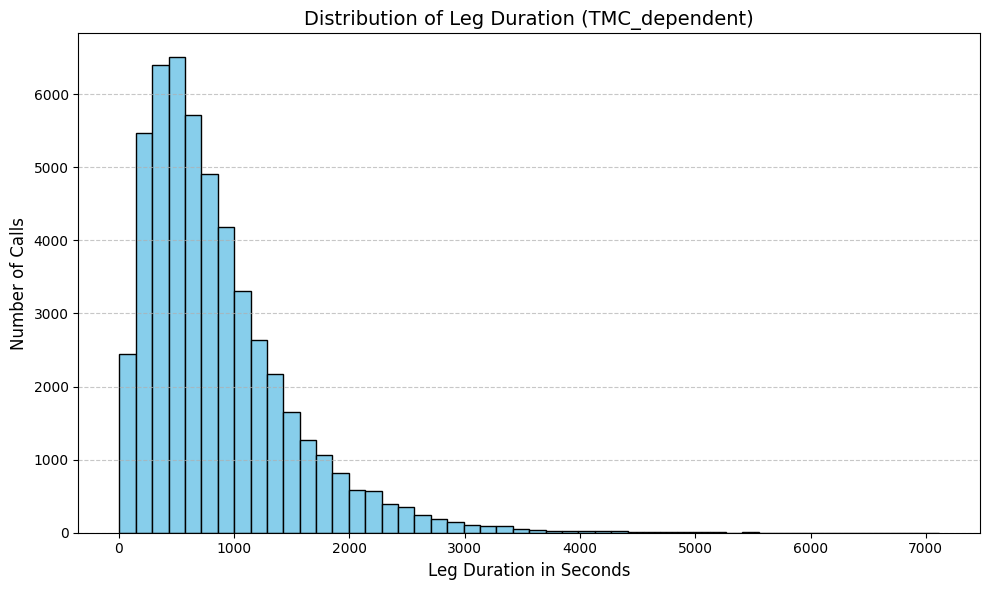

In [7]:
# Create TMC_dependent
full_merged_df['TMC_dependent'] = full_merged_df['call_LEG_DURATION_SEC_QTY']

# Plot the distribution
plt.figure(figsize=(10, 6))
plt.hist(full_merged_df['TMC_dependent'], bins=50, edgecolor='black', color='skyblue')
plt.title('Distribution of Leg Duration (TMC_dependent)', fontsize=14)
plt.xlabel('Leg Duration in Seconds', fontsize=12)
plt.ylabel('Number of Calls', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()


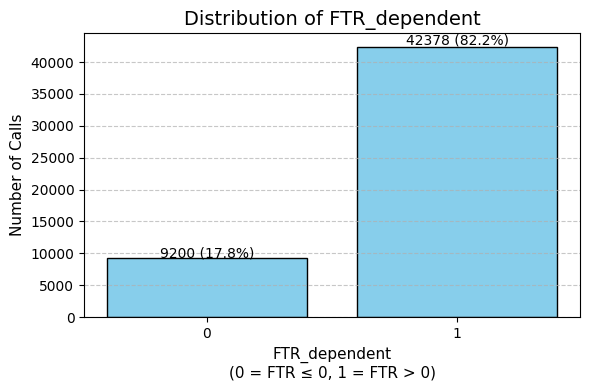

In [8]:
# Create FTR_dependent
full_merged_df['FTR_dependent'] = (full_merged_df['call_FTR_CALCULATED'] > 0).astype(int)

# Revert all other FTR colums as well
ftr_columns = [col for col in full_merged_df.columns if 'FTR' in col]
for col in ftr_columns:
    full_merged_df[col] = 1 - full_merged_df[col]

# Plot distribution
ftr_counts = full_merged_df['FTR_dependent'].value_counts().sort_index()
ftr_percent = ftr_counts / ftr_counts.sum() * 100

plt.figure(figsize=(6, 4))
bars = plt.bar(ftr_counts.index.astype(str), ftr_counts.values, color='skyblue', edgecolor='black')
plt.title('Distribution of FTR_dependent', fontsize=14)
plt.xlabel('FTR_dependent\n(0 = FTR ≤ 0, 1 = FTR > 0)', fontsize=11)
plt.ylabel('Number of Calls', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Add count and % labels
for i, (count, pct) in enumerate(zip(ftr_counts.values, ftr_percent)):
    plt.text(i, count + count*0.01, f'{count} ({pct:.1f}%)', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

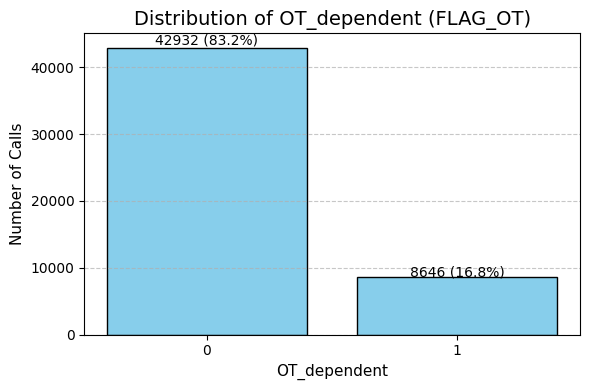

In [9]:
# Create OT_dependent
full_merged_df['OT_dependent'] = full_merged_df['call_FLAG_OT']

# Plot distribution
ot_counts = full_merged_df['OT_dependent'].value_counts().sort_index()
ot_percent = ot_counts / ot_counts.sum() * 100

plt.figure(figsize=(6, 4))
bars = plt.bar(ot_counts.index.astype(str), ot_counts.values, color='skyblue', edgecolor='black')
plt.title('Distribution of OT_dependent (FLAG_OT)', fontsize=14)
plt.xlabel('OT_dependent', fontsize=11)
plt.ylabel('Number of Calls', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Add count and % labels
for i, (count, pct) in enumerate(zip(ot_counts.values, ot_percent)):
    plt.text(i, count + count*0.01, f'{count} ({pct:.1f}%)', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [10]:
print(full_merged_df[['call_FTR_CALCULATED', 'call_FLAG_OT']].describe())
print(full_merged_df['FTR_dependent'].value_counts(normalize=True))
print(full_merged_df['OT_dependent'].value_counts(normalize=True))


       call_FTR_CALCULATED  call_FLAG_OT
count         51578.000000  51578.000000
mean              0.840848      0.167630
std               0.353206      0.373541
min               0.000000      0.000000
25%               1.000000      0.000000
50%               1.000000      0.000000
75%               1.000000      0.000000
max               1.000000      1.000000
FTR_dependent
1    0.821629
0    0.178371
Name: proportion, dtype: float64
OT_dependent
0    0.83237
1    0.16763
Name: proportion, dtype: float64


### 1.2.2. <a id='toc1_2_2_'></a>[Feature Engineering](#toc0_)

In [11]:
# Convert call_CALL_START_TIME_DAT	call_CALL_END_TIME_DAT	call_LEG_START_TIME_DAT	call_LEG_END_TIME_DAT to datetime
full_merged_df["call_CALL_START_TIME_DAT"] = pd.to_datetime(full_merged_df["call_CALL_START_TIME_DAT"])
full_merged_df["call_CALL_END_TIME_DAT"] = pd.to_datetime(full_merged_df["call_CALL_END_TIME_DAT"])
full_merged_df["call_LEG_START_TIME_DAT"] = pd.to_datetime(full_merged_df["call_LEG_START_TIME_DAT"])
full_merged_df["call_LEG_END_TIME_DAT"] = pd.to_datetime(full_merged_df["call_LEG_END_TIME_DAT"])


In [12]:
# Feature Engineering
# 1. Calls in the last 7 days (0 for no, 1 for yes)
# 2. Days since last call (Client)
# 3. Tipicification level 2
# 4. Days since last call (GC)
# 5. Weekday or Weekend
# 6. Time of day (Morning, Afternoon, Evening, Night)


#### 1.2.2.1. <a id='toc1_2_2_1_'></a>[Calls in the last 7 days](#toc0_)

In [13]:
# 1. Calls in the last 7 days (Client)
# This requires knowing the previous call time for the same client.
# First, sort by client and then by call time to correctly identify previous calls.
full_merged_df = full_merged_df.sort_values(by=['call_PERSON_ID', 'call_CALL_START_TIME_DAT'])

# Get the previous call time for each client
full_merged_df['previous_call_time_client'] = full_merged_df.groupby('call_PERSON_ID')['call_CALL_START_TIME_DAT'].shift(1)

# Calculate days since the previous call for that client
full_merged_df['days_since_prev_call_for_client'] = (full_merged_df['call_CALL_START_TIME_DAT'] - full_merged_df['previous_call_time_client']).dt.days

# Feature: 1 if there was a call from this client in the last 7 days (relative to the current call), 0 otherwise
# For the first call of a client, 'days_since_prev_call_for_client' will be NaN.
full_merged_df['client_called_in_last_7_days'] = full_merged_df['days_since_prev_call_for_client'].apply(lambda x: 1 if pd.notna(x) and x <= 7 else 0)

#### 1.2.2.2. <a id='toc1_2_2_2_'></a>[Days since last call (Client)](#toc0_)

In [14]:
# 2. Days since last call (Client)
# This is essentially 'days_since_prev_call_for_client' calculated above.
# We might want to fill NaNs for clients with no prior calls (e.g., with -1 or a large number).
# For this example, let's keep it as is, or fill with a placeholder like -1.
full_merged_df['days_since_prev_call_for_client'] = full_merged_df['days_since_prev_call_for_client'].fillna(-1).astype(int)
full_merged_df['days_since_last_call_client'] = full_merged_df['days_since_prev_call_for_client'] # Or keep NaN if preferred


#### 1.2.2.3. <a id='toc1_2_2_3_'></a>[Tipification level 2](#toc0_)

In [15]:
def enrich_with_lvl2_topic_features(df, person_col="PERSON_SK"):
    """
    Adds historical Level 2 topic features:
    - Lagged topic category
    - Cumulative topic counts
    - Proportions over client history
    - One-hot lag features
    - First-call flag
    """
    df = df.copy()

    # --- 1. 'TV' to 'TELEVISÃO' ---
    df["call_TOPIC_TIPIFICATION_LVL_2_DSC"] = df["call_TOPIC_TIPIFICATION_LVL_2_DSC"].replace("TV", "TELEVISÃO")

    # --- 2. Group Level 2 topics ---
    topics_to_keep_lvl2 = {
        "INTERNET FIXA", "TELEVISÃO", "BOX", "VOZ FIXA",
        "ADESÃO/ALTERAÇÃO", "SEM VOZ DE CLIENTE", "MAIS INFORMAÇÕES", "CARTÃO SIM/ESIM/TWIN"
    }
    df["TOPIC_LVL_2_GROUPED"] = df["call_TOPIC_TIPIFICATION_LVL_2_DSC"].apply(
        lambda x: x if x in topics_to_keep_lvl2 else "OUTROS"
    )

    # --- 3. Lagged topic (string-based), fill missing with 'NO_PREV_CALL' ---
    df["TOPIC_LVL_2_GROUPED_LAG1_STR"] = df.groupby(person_col)["TOPIC_LVL_2_GROUPED"].shift(1).fillna("NO_PREV_CALL")

    # --- 4. One-hot dummies for counting, drop dummy lag class ---
    lvl2_dummies = pd.get_dummies(df["TOPIC_LVL_2_GROUPED_LAG1_STR"], prefix="CNT_LVL2")
    lvl2_dummies = lvl2_dummies.drop(columns=[col for col in lvl2_dummies if "NO_PREV_CALL" in col], errors='ignore')

    # --- 5. Cumulative topic count ---
    lvl2_counts = lvl2_dummies.groupby(df[person_col]).cumsum()
    df = pd.concat([df, lvl2_counts], axis=1)

    # --- 6. Cumulative call number per client ---
    df["CUM_TOTAL_CALLS"] = df.groupby(person_col).cumcount()

    # --- 7. Proportional features ---
    for col in lvl2_counts.columns:
        df[col.replace("CNT_", "PROP_")] = lvl2_counts[col] / (df["CUM_TOTAL_CALLS"] + 1)

    # --- 8. One-hot encode lag string for model use (keep 'NO_PREV_CALL') ---
    lag1_l2_encoded = pd.get_dummies(df["TOPIC_LVL_2_GROUPED_LAG1_STR"], prefix="LAG1_LVL2", drop_first=False)
    df = pd.concat([df, lag1_l2_encoded.astype(int)], axis=1)

    # --- 9. First call flag ---
    df["IS_FIRST_CALL"] = (df["CUM_TOTAL_CALLS"] == 0).astype(int)

    return df

full_merged_df = enrich_with_lvl2_topic_features(full_merged_df)

In [16]:
features_to_include = [
    "IS_FIRST_CALL"
]

# Add all CNT_LVL2_* columns
features_to_include += [col for col in full_merged_df.columns if col.startswith("CNT_LVL2_")]

# Add all PROP_LVL2_* columns
features_to_include += [col for col in full_merged_df.columns if col.startswith("PROP_LVL2_")]

# Add all LAG1_LVL2_* columns
features_to_include += [col for col in full_merged_df.columns if col.startswith("LAG1_LVL2_")]

print("Features to include:")
for feature in features_to_include:
    print(feature)

Features to include:
IS_FIRST_CALL
CNT_LVL2_ADESÃO/ALTERAÇÃO
CNT_LVL2_BOX
CNT_LVL2_CARTÃO SIM/ESIM/TWIN
CNT_LVL2_INTERNET FIXA
CNT_LVL2_MAIS INFORMAÇÕES
CNT_LVL2_OUTROS
CNT_LVL2_SEM VOZ DE CLIENTE
CNT_LVL2_TELEVISÃO
CNT_LVL2_VOZ FIXA
PROP_LVL2_ADESÃO/ALTERAÇÃO
PROP_LVL2_BOX
PROP_LVL2_CARTÃO SIM/ESIM/TWIN
PROP_LVL2_INTERNET FIXA
PROP_LVL2_MAIS INFORMAÇÕES
PROP_LVL2_OUTROS
PROP_LVL2_SEM VOZ DE CLIENTE
PROP_LVL2_TELEVISÃO
PROP_LVL2_VOZ FIXA
LAG1_LVL2_ADESÃO/ALTERAÇÃO
LAG1_LVL2_BOX
LAG1_LVL2_CARTÃO SIM/ESIM/TWIN
LAG1_LVL2_INTERNET FIXA
LAG1_LVL2_MAIS INFORMAÇÕES
LAG1_LVL2_NO_PREV_CALL
LAG1_LVL2_OUTROS
LAG1_LVL2_SEM VOZ DE CLIENTE
LAG1_LVL2_TELEVISÃO
LAG1_LVL2_VOZ FIXA


#### 1.2.2.4. <a id='toc1_2_2_4_'></a>[Days since last call (GC - Group Key)](#toc0_)

In [17]:
# 4. Days since last call (GC - Group Key)
# Similar to client, but grouping by 'RESOURCE_KEY'
full_merged_df = full_merged_df.sort_values(by=['RESOURCE_KEY', 'call_CALL_START_TIME_DAT']) # Ensure sort order for GC
full_merged_df['previous_call_time_gc'] = full_merged_df.groupby('RESOURCE_KEY')['call_CALL_START_TIME_DAT'].shift(1)
full_merged_df['days_since_last_call_gc'] = (full_merged_df['call_CALL_START_TIME_DAT'] - full_merged_df['previous_call_time_gc']).dt.days

# We might want to fill NaNs for clients with no prior calls (e.g., with -1 or a large number).
# For this example, let's keep it as is, or fill with a placeholder like -1.
full_merged_df['days_since_last_call_gc'] = full_merged_df['days_since_last_call_gc'].fillna(-1).astype(int) # Or keep NaN


#### 1.2.2.5. <a id='toc1_2_2_5_'></a>[Weekday or Weekend](#toc0_)

In [18]:
# 5. Weekday or Weekend
# 0 is Monday, 6 is Sunday. So, 5 (Saturday) and 6 (Sunday) are weekends.
full_merged_df['day_of_week'] = full_merged_df['call_CALL_START_TIME_DAT'].dt.dayofweek
full_merged_df['is_weekend'] = full_merged_df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0) # 1 for weekend, 0 for weekday
# Or as string categories:
full_merged_df['weekday_or_weekend_str'] = full_merged_df['day_of_week'].apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')

#### 1.2.2.6. <a id='toc1_2_2_6_'></a>[Time of day](#toc0_)

In [19]:
# 6. Time of day (Morning, Afternoon, Evening, Night)
def get_time_of_day(hour):
    if 5 <= hour < 12:
        return 'Morning'  # 5 AM to 11:59 AM
    elif 12 <= hour < 18:
        return 'Afternoon' # 12 PM to 5:59 PM
    elif 18 <= hour < 22:
        return 'Evening'   # 6 PM to 9:59 PM
    else:
        return 'Night'     # 10 PM to 4:59 AM

full_merged_df['hour_of_day'] = full_merged_df['call_CALL_START_TIME_DAT'].dt.hour
full_merged_df['time_of_day_str'] = full_merged_df['hour_of_day'].apply(get_time_of_day)

#### 1.2.2.7. <a id='toc1_2_2_7_'></a>[Topic Classification Entry at FT - PREVIOUS CALL](#toc0_)

In [20]:
# Lagged feature: topic of the previous call per client
full_merged_df["PREV_CALL_TOPIC_CLASSIFIC_ENTRY_AT_FT"] = (
    full_merged_df.groupby("PERSON_SK")["call_TOPIC_CLASSIFIC_ENTRY_AT_FT"].shift(1)
)

In [21]:
full_merged_df.head()

,call_Column1,call_LEG_IF_ID,call_PERSON_ID,PERSON_SK,call_CALL_IF_ID,call_GROUP_KEY,RESOURCE_KEY,call_NR_RPC_0,call_NR_RPC_1,call_NR_INCIDENTS_PER_LEG,call_CALL_START_TIME_DAT,call_CALL_END_TIME_DAT,call_LEG_START_TIME_DAT,call_LEG_END_TIME_DAT,call_LEG_DURATION_SEC_QTY,call_CALL_DURATION_SEQ_QTY,call_TOPIC_TIPIFICATION_LVL_1_DSC,call_TOPIC_TIPIFICATION_LVL_2_DSC,call_TOPIC_TIPIFICATION_LVL_3_DSC,call_TOPIC_CLASSIFIC_ENTRY_AT_FT,call_WORK_ORDER_ID,call_TIBCO_DIFFUSION_DAT,call_TOPIC_INCIDENT_COD_COUNT,call_FTR_1_SUM,call_FTR_CALCULATED,call_WORK_ORDER_SCHEDULE_END_DAT,call_FLAG_OT,call_FTR_Actual_1,call_CALL_START_TIME_DAT_normalized,client_Column1,client_FISCAL_NUM,client_START_DATE,client_PERSON_ID,client_CA_COD,client_SA_COD,client_LEG_START_TIME_DAY,client_DAT_CRI_SA,client_DT_NASC,client_CLIENT_AGE_YEARS,client_CLIENT_ANTIQUITY_YEARS,client_NR_SAS,client_ARPU_CALCULATED,client_SERVICES_QTY,client_TV_PROD_FLG,client_IF_PROD_FLG,client_VF_PROD_FLG,client_VM_PROD_FLG,client_IM_PROD_FLG,client_TECH_COPPER_FLG,client_TECH_CABLE_FLG,client_TECH_FTTH_FLG,client_TECH_DTH_FLG,client_TECH_GSM_FLG,client_TV_SPTV_FLG,client_TV_BTV_FLG,client_TV_11SPORTS_FLG,client_TV_TVCINE_FLG,client_IF_DOWNLOAD_SPEED_MBPS_QTY,client_IF_UPLOAD_SPEED_KBPS_QTY,client_FLG_BOX_1_HD_SAT,client_FLG_BOX_1_HD_PLUS_DVR_SAT_TDT,client_FLG_BOX_2_HD_CABO,client_FLG_BOX_2_HD_PLUS_DVR_CABO,client_FLG_BOX_3_ULTRA_HD,client_FLG_NO_BOX,client_FLG_UNKNOWN,client_FLG_CONSUMER,client_FLG_EMPRESARIAL,client_FLG_ILHAS,client_FLG_INDEFINIDO,client_ARPU_CLIENT,client_PF_CLIENT_MONTHS,client_LEG_DURATION_MEAN_180_ASSUNTO_IF,client_LEG_DURATION_MEAN_180_ASSUNTO_MOVEL,client_LEG_DURATION_MEAN_180_ASSUNTO_OTHER,client_LEG_DURATION_MEAN_180_ASSUNTO_TV,client_LEG_DURATION_MEAN_180_ASSUNTO_VF,client_LEG_DURATION_MEAN_180_TOTAL,client_LEG_DURATION_MEAN_365_ASSUNTO_IF,client_LEG_DURATION_MEAN_365_ASSUNTO_MOVEL,client_LEG_DURATION_MEAN_365_ASSUNTO_OTHER,client_LEG_DURATION_MEAN_365_ASSUNTO_TV,client_LEG_DURATION_MEAN_365_ASSUNTO_VF,client_LEG_DURATION_MEAN_365_TOTAL,client_RPC_MEAN_180_ASSUNTO_IF,client_RPC_MEAN_180_ASSUNTO_MOVEL,client_RPC_MEAN_180_ASSUNTO_OTHER,client_RPC_MEAN_180_ASSUNTO_TV,client_RPC_MEAN_180_ASSUNTO_VF,client_RPC_MEAN_180_TOTAL,client_RPC_MEAN_365_ASSUNTO_IF,client_RPC_MEAN_365_ASSUNTO_MOVEL,client_RPC_MEAN_365_ASSUNTO_OTHER,client_RPC_MEAN_365_ASSUNTO_TV,client_RPC_MEAN_365_ASSUNTO_VF,client_RPC_MEAN_365_TOTAL,client_FTR_CALCULATED_MEAN_180_ASSUNTO_IF,client_FTR_CALCULATED_MEAN_180_ASSUNTO_MOVEL,client_FTR_CALCULATED_MEAN_180_ASSUNTO_OTHER,client_FTR_CALCULATED_MEAN_180_ASSUNTO_TV,client_FTR_CALCULATED_MEAN_180_ASSUNTO_VF,client_FTR_CALCULATED_MEAN_180_TOTAL,client_FTR_CALCULATED_MEAN_365_ASSUNTO_IF,client_FTR_CALCULATED_MEAN_365_ASSUNTO_MOVEL,client_FTR_CALCULATED_MEAN_365_ASSUNTO_OTHER,client_FTR_CALCULATED_MEAN_365_ASSUNTO_TV,client_FTR_CALCULATED_MEAN_365_ASSUNTO_VF,client_FTR_CALCULATED_MEAN_365_TOTAL,client_LEG_IF_ID_COUNT_180_ASSUNTO_IF,client_LEG_IF_ID_COUNT_180_ASSUNTO_MOVEL,client_LEG_IF_ID_COUNT_180_ASSUNTO_OTHER,client_LEG_IF_ID_COUNT_180_ASSUNTO_TV,client_LEG_IF_ID_COUNT_180_ASSUNTO_VF,client_LEG_IF_ID_COUNT_180_TOTAL,client_LEG_IF_ID_COUNT_365_ASSUNTO_IF,client_LEG_IF_ID_COUNT_365_ASSUNTO_MOVEL,client_LEG_IF_ID_COUNT_365_ASSUNTO_OTHER,client_LEG_IF_ID_COUNT_365_ASSUNTO_TV,client_LEG_IF_ID_COUNT_365_ASSUNTO_VF,client_LEG_IF_ID_COUNT_365_TOTAL,client_NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_IF,client_NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_MOVEL,client_NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_OTHER,client_NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_TV,client_NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_VF,client_NR_INCIDENTS_PER_LEG_SUM_180_TOTAL,client_NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_IF,client_NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_MOVEL,client_NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_OTHER,client_NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_TV,client_NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_VF,client_NR_INCIDENTS_PER_LEG_SUM_365_TOTAL,client_CALL_IF_ID_NUNIQUE_180_ASSUNTO_IF,client_C

### 1.2.3. <a id='toc1_2_3_'></a>[Create Baseline Prediction Columns (Rule-Based Average Targets per Cat)](#toc0_)

In [22]:
# Calculate average duration and resolution rate per call_TOPIC_CLASSIFIC_ENTRY_AT_FT
avg_duration = full_merged_df.groupby('call_TOPIC_CLASSIFIC_ENTRY_AT_FT')['call_CALL_DURATION_SEQ_QTY'].mean()
avg_resolution_rate = full_merged_df.groupby('call_TOPIC_CLASSIFIC_ENTRY_AT_FT')['FTR_dependent'].mean()#
avg_ot_rate = full_merged_df.groupby('call_TOPIC_CLASSIFIC_ENTRY_AT_FT')['OT_dependent'].mean()

# Create a DataFrame to hold the average duration and resolution rate
avg_resolution_df = pd.DataFrame({
    'avg_duration': avg_duration,
    'avg_resolution_rate': avg_resolution_rate,
    'avg_ot_rate': avg_ot_rate
}).reset_index()

# Rename the columns for clarity
avg_resolution_df.columns = ['call_TOPIC_CLASSIFIC_ENTRY_AT_FT', 'avg_duration', 'avg_resolution_rate', 'avg_ot_rate']

# Merge the average duration and resolution rate back into the main DataFrame
full_merged_df = full_merged_df.merge(avg_resolution_df, on='call_TOPIC_CLASSIFIC_ENTRY_AT_FT', how='left')

# Set random seed for reproducibility
np.random.seed(42)

# Create baseline predictions using a "manipulated coin flip"
full_merged_df["Predicted_FTR_BASELINE"] = full_merged_df["avg_resolution_rate"].apply(
    lambda x: 1 if np.random.rand() < x else 0
)

In [23]:
full_merged_df.columns.tolist()[-10:]

['day_of_week',
 'is_weekend',
 'weekday_or_weekend_str',
 'hour_of_day',
 'time_of_day_str',
 'PREV_CALL_TOPIC_CLASSIFIC_ENTRY_AT_FT',
 'avg_duration',
 'avg_resolution_rate',
 'avg_ot_rate',
 'Predicted_FTR_BASELINE']

### 1.2.4. <a id='toc1_2_4_'></a>[Select relevant columns](#toc0_)

In [24]:
# Save non-feature identifiers separately
id_columns = full_merged_df[['call_LEG_IF_ID', 'RESOURCE_KEY']]

In [25]:
# Create reduced_df by selecting specific columns (preserving original order)
# HERE YOU CAN SELECT THE COLUMNS BY # WHICH WILL THEN BE USED FOR MODELING (DEPENDENT VARIABLES CANNOT BE DESELECTED)

reduced_df = full_merged_df[[
    "call_LEG_IF_ID",
    # "PERSON_SK",
    # "call_CALL_IF_ID",
    # "RESOURCE_KEY",
    # "call_NR_RPC_0",
    # "call_NR_RPC_1",
    # "call_NR_INCIDENTS_PER_LEG",
    # "call_CALL_START_TIME_DAT",
    # "call_CALL_END_TIME_DAT",
    # "call_LEG_START_TIME_DAT",
    # "call_LEG_END_TIME_DAT",
    # "call_LEG_DURATION_SEC_QTY",
    # "call_CALL_DURATION_SEQ_QTY",
    # "call_TOPIC_TIPIFICATION_LVL_1_DSC",
    # "call_TOPIC_TIPIFICATION_LVL_2_DSC",
    # "call_TOPIC_TIPIFICATION_LVL_3_DSC",
    "call_TOPIC_CLASSIFIC_ENTRY_AT_FT",
    # "call_WORK_ORDER_ID",
    # "call_TIBCO_DIFFUSION_DAT",
    # "call_TOPIC_INCIDENT_COD_COUNT",
    # "call_FTR_CALCULATED",
    # "call_WORK_ORDER_SCHEDULE_END_DAT",
    # "call_FLAG_OT",
    # "call_CALL_START_TIME_DAT_normalized",
    "gc_COUNT_CALLS",
    "gc_DAYS_ACTIVE",
    # "gc_MEAN_RPC",
    "gc_MEAN_FTR",
    "gc_MEAN_TMC",
    "gc_OTS_BY_CALL",
    "gc_COUNT_CALLS_IF",
    # "gc_MEAN_RPC_IF",
    "gc_MEAN_FTR_IF",
    "gc_MEAN_TMC_IF",
    "gc_TOTAL_OTS_IF",
    "gc_OTS_BY_CALL_IF",
    "gc_COUNT_CALLS_OTHER",
    # "gc_MEAN_RPC_OTHER",
    "gc_MEAN_FTR_OTHER",
    "gc_MEAN_TMC_OTHER",
    "gc_TOTAL_OTS_OTHER",
    "gc_OTS_BY_CALL_OTHER",
    "gc_COUNT_CALLS_VF",
    # "gc_MEAN_RPC_VF",
    "gc_MEAN_FTR_VF",
    "gc_MEAN_TMC_VF",
    "gc_TOTAL_OTS_VF",
    "gc_OTS_BY_CALL_VF",
    "gc_COUNT_CALLS_TV",
    # "gc_MEAN_RPC_TV",
    "gc_MEAN_FTR_TV",
    "gc_MEAN_TMC_TV",
    "gc_TOTAL_OTS_TV",
    "gc_OTS_BY_CALL_TV",
    "gc_COUNT_CALLS_MOVEL",
    # "gc_MEAN_RPC_MOVEL",
    "gc_MEAN_FTR_MOVEL",
    "gc_MEAN_TMC_MOVEL",
    "gc_TOTAL_OTS_MOVEL",
    # "gc_OTS_BY_CALL_MOVEL",
    "gc_CALLS_IF_BINARY",
    "gc_CALLS_OTHER_BINARY",
    "gc_CALLS_VF_BINARY",
    "gc_CALLS_TV_BINARY",
    "gc_CALLS_MOVEL_BINARY",
    # "client_Column1",
    # "client_FISCAL_NUM",
    # "client_START_DATE",
    # "client_PERSON_ID",
    # "client_CA_COD",
    # "client_SA_COD",
    # "client_LEG_START_TIME_DAY",
    # "client_DAT_CRI_SA",
    # "client_DT_NASC",
    "client_CLIENT_AGE_YEARS",
    "client_CLIENT_ANTIQUITY_YEARS",
    "client_NR_SAS",
    "client_ARPU_CALCULATED",
    "client_ARPU_CLIENT",
    "client_PF_CLIENT_MONTHS",
    # "client_LEG_DURATION_MEAN_180_ASSUNTO_IF",
    # "client_LEG_DURATION_MEAN_180_ASSUNTO_MOVEL",
    # "client_LEG_DURATION_MEAN_180_ASSUNTO_OTHER",
    # "client_LEG_DURATION_MEAN_180_ASSUNTO_TV",
    # "client_LEG_DURATION_MEAN_180_ASSUNTO_VF",
    # "client_LEG_DURATION_MEAN_180_TOTAL",
    "client_LEG_DURATION_MEAN_365_ASSUNTO_IF",
    "client_LEG_DURATION_MEAN_365_ASSUNTO_MOVEL",
    "client_LEG_DURATION_MEAN_365_ASSUNTO_OTHER",
    "client_LEG_DURATION_MEAN_365_ASSUNTO_TV",
    "client_LEG_DURATION_MEAN_365_ASSUNTO_VF",
    "client_LEG_DURATION_MEAN_365_TOTAL",
    # "client_RPC_MEAN_180_ASSUNTO_IF",
    # "client_RPC_MEAN_180_ASSUNTO_MOVEL",
    # "client_RPC_MEAN_180_ASSUNTO_OTHER",
    # "client_RPC_MEAN_180_ASSUNTO_TV",
    # "client_RPC_MEAN_180_ASSUNTO_VF",
    # "client_RPC_MEAN_180_TOTAL",
    "client_RPC_MEAN_365_ASSUNTO_IF",
    "client_RPC_MEAN_365_ASSUNTO_MOVEL",
    "client_RPC_MEAN_365_ASSUNTO_OTHER",
    "client_RPC_MEAN_365_ASSUNTO_TV",
    "client_RPC_MEAN_365_ASSUNTO_VF",
    "client_RPC_MEAN_365_TOTAL",
    # "client_FTR_CALCULATED_MEAN_180_ASSUNTO_IF",
    # "client_FTR_CALCULATED_MEAN_180_ASSUNTO_MOVEL",
    # "client_FTR_CALCULATED_MEAN_180_ASSUNTO_OTHER",
    # "client_FTR_CALCULATED_MEAN_180_ASSUNTO_TV",
    # "client_FTR_CALCULATED_MEAN_180_ASSUNTO_VF",
    # "client_FTR_CALCULATED_MEAN_180_TOTAL",
    "client_FTR_CALCULATED_MEAN_365_ASSUNTO_IF",
    "client_FTR_CALCULATED_MEAN_365_ASSUNTO_MOVEL",
    "client_FTR_CALCULATED_MEAN_365_ASSUNTO_OTHER",
    "client_FTR_CALCULATED_MEAN_365_ASSUNTO_TV",
    "client_FTR_CALCULATED_MEAN_365_ASSUNTO_VF",
    "client_FTR_CALCULATED_MEAN_365_TOTAL",
    # "client_LEG_IF_ID_COUNT_180_ASSUNTO_IF",
    # "client_LEG_IF_ID_COUNT_180_ASSUNTO_MOVEL",
    # "client_LEG_IF_ID_COUNT_180_ASSUNTO_OTHER",
    # "client_LEG_IF_ID_COUNT_180_ASSUNTO_TV",
    # "client_LEG_IF_ID_COUNT_180_ASSUNTO_VF",
    # "client_LEG_IF_ID_COUNT_180_TOTAL",
    "client_NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_IF",
    "client_NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_MOVEL",
    "client_NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_OTHER",
    "client_NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_TV",
    "client_NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_VF",
    "client_NR_INCIDENTS_PER_LEG_SUM_365_TOTAL",
    "client_CALL_IF_ID_NUNIQUE_365_ASSUNTO_IF",
    "client_CALL_IF_ID_NUNIQUE_365_ASSUNTO_MOVEL",
    "client_CALL_IF_ID_NUNIQUE_365_ASSUNTO_OTHER",
    "client_CALL_IF_ID_NUNIQUE_365_ASSUNTO_TV",
    "client_CALL_IF_ID_NUNIQUE_365_ASSUNTO_VF",
    "client_CALL_IF_ID_NUNIQUE_365_TOTAL",
    "client_Age_missing",
    "TMC_dependent",
    "FTR_dependent",
    "OT_dependent",
    # 'previous_call_time_client',
    # 'days_since_last_call_client',
    #"calls_in_last_7_days_client", # number of calls in the last 7 days
    'days_since_prev_call_for_client', # days since last call for the client
    'client_called_in_last_7_days', # 1 if there was a call from this client in the last 7 days, 0 otherwise
    # 'previous_call_time_gc',
    'days_since_last_call_gc',	# days since last call for the Resource Key
    # 'day_of_week'	,
    'is_weekend' ,	# 1 for weekend, 0 for weekday
    # 'weekday_or_weekend_str',	# Weekday or Weekend
    'hour_of_day',	# hour of the day (0-23)
    # 'time_of_day_str',     # Time of day (Morning, Afternoon, Evening, Night)
    'IS_FIRST_CALL',
    'CNT_LVL2_ADESÃO/ALTERAÇÃO',
    'CNT_LVL2_BOX',
    'CNT_LVL2_CARTÃO SIM/ESIM/TWIN',
    'CNT_LVL2_INTERNET FIXA',
    'CNT_LVL2_MAIS INFORMAÇÕES',
    'CNT_LVL2_OUTROS',
    'CNT_LVL2_SEM VOZ DE CLIENTE',
    'CNT_LVL2_TELEVISÃO',
    'CNT_LVL2_VOZ FIXA',
    'PROP_LVL2_ADESÃO/ALTERAÇÃO',
    'PROP_LVL2_BOX',
    'PROP_LVL2_CARTÃO SIM/ESIM/TWIN',
    'PROP_LVL2_INTERNET FIXA',
    'PROP_LVL2_MAIS INFORMAÇÕES',
    'PROP_LVL2_OUTROS',
    'PROP_LVL2_SEM VOZ DE CLIENTE',
    'PROP_LVL2_TELEVISÃO',
    'PROP_LVL2_VOZ FIXA',
    'LAG1_LVL2_ADESÃO/ALTERAÇÃO',
    'LAG1_LVL2_BOX',
    'LAG1_LVL2_CARTÃO SIM/ESIM/TWIN',
    'LAG1_LVL2_INTERNET FIXA',
    'LAG1_LVL2_MAIS INFORMAÇÕES',
    #'LAG1_LVL2_NO_PREV_CALL',
    'LAG1_LVL2_OUTROS',
    'LAG1_LVL2_SEM VOZ DE CLIENTE',
    'LAG1_LVL2_TELEVISÃO',
    'LAG1_LVL2_VOZ FIXA',
    'avg_duration',
    "avg_resolution_rate",
    'Predicted_FTR_BASELINE',
    'avg_ot_rate',
    "PREV_CALL_TOPIC_CLASSIFIC_ENTRY_AT_FT"
]].copy()
reduced_df=reduced_df.dropna()
reduced_df.head()

,call_LEG_IF_ID,call_TOPIC_CLASSIFIC_ENTRY_AT_FT,gc_COUNT_CALLS,gc_DAYS_ACTIVE,gc_MEAN_FTR,gc_MEAN_TMC,gc_OTS_BY_CALL,gc_COUNT_CALLS_IF,gc_MEAN_FTR_IF,gc_MEAN_TMC_IF,gc_TOTAL_OTS_IF,gc_OTS_BY_CALL_IF,gc_COUNT_CALLS_OTHER,gc_MEAN_FTR_OTHER,gc_MEAN_TMC_OTHER,gc_TOTAL_OTS_OTHER,gc_OTS_BY_CALL_OTHER,gc_COUNT_CALLS_VF,gc_MEAN_FTR_VF,gc_MEAN_TMC_VF,gc_TOTAL_OTS_VF,gc_OTS_BY_CALL_VF,gc_COUNT_CALLS_TV,gc_MEAN_FTR_TV,gc_MEAN_TMC_TV,gc_TOTAL_OTS_TV,gc_OTS_BY_CALL_TV,gc_COUNT_CALLS_MOVEL,gc_MEAN_FTR_MOVEL,gc_MEAN_TMC_MOVEL,gc_TOTAL_OTS_MOVEL,gc_CALLS_IF_BINARY,gc_CALLS_OTHER_BINARY,gc_CALLS_VF_BINARY,gc_CALLS_TV_BINARY,gc_CALLS_MOVEL_BINARY,client_CLIENT_AGE_YEARS,client_CLIENT_ANTIQUITY_YEARS,client_NR_SAS,client_ARPU_CALCULATED,client_ARPU_CLIENT,client_PF_CLIENT_MONTHS,client_LEG_DURATION_MEAN_365_ASSUNTO_IF,client_LEG_DURATION_MEAN_365_ASSUNTO_MOVEL,client_LEG_DURATION_MEAN_365_ASSUNTO_OTHER,client_LEG_DURATION_MEAN_365_ASSUNTO_TV,client_LEG_DURATION_MEAN_365_ASSUNTO_VF,client_LEG_DURATION_MEAN_365_TOTAL,client_RPC_MEAN_365_ASSUNTO_IF,client_RPC_MEAN_365_ASSUNTO_MOVEL,client_RPC_MEAN_365_ASSUNTO_OTHER,client_RPC_MEAN_365_ASSUNTO_TV,client_RPC_MEAN_365_ASSUNTO_VF,client_RPC_MEAN_365_TOTAL,client_FTR_CALCULATED_MEAN_365_ASSUNTO_IF,client_FTR_CALCULATED_MEAN_365_ASSUNTO_MOVEL,client_FTR_CALCULATED_MEAN_365_ASSUNTO_OTHER,client_FTR_CALCULATED_MEAN_365_ASSUNTO_TV,client_FTR_CALCULATED_MEAN_365_ASSUNTO_VF,client_FTR_CALCULATED_MEAN_365_TOTAL,client_NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_IF,client_NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_MOVEL,client_NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_OTHER,client_NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_TV,client_NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_VF,client_NR_INCIDENTS_PER_LEG_SUM_365_TOTAL,client_CALL_IF_ID_NUNIQUE_365_ASSUNTO_IF,client_CALL_IF_ID_NUNIQUE_365_ASSUNTO_MOVEL,client_CALL_IF_ID_NUNIQUE_365_ASSUNTO_OTHER,client_CALL_IF_ID_NUNIQUE_365_ASSUNTO_TV,client_CALL_IF_ID_NUNIQUE_365_ASSUNTO_VF,client_CALL_IF_ID_NUNIQUE_365_TOTAL,client_Age_missing,TMC_dependent,FTR_dependent,OT_dependent,days_since_prev_call_for_client,client_called_in_last_7_days,days_since_last_call_gc,is_weekend,hour_of_day,IS_FIRST_CALL,CNT_LVL2_ADESÃO/ALTERAÇÃO,CNT_LVL2_BOX,CNT_LVL2_CARTÃO SIM/ESIM/TWIN,CNT_LVL2_INTERNET FIXA,CNT_LVL2_MAIS INFORMAÇÕES,CNT_LVL2_OUTROS,CNT_LVL2_SEM VOZ DE CLIENTE,CNT_LVL2_TELEVISÃO,CNT_LVL2_VOZ FIXA,PROP_LVL2_ADESÃO/ALTERAÇÃO,PROP_LVL2_BOX,PROP_LVL2_CARTÃO SIM/ESIM/TWIN,PROP_LVL2_INTERNET FIXA,PROP_LVL2_MAIS INFORMAÇÕES,PROP_LVL2_OUTROS,PROP_LVL2_SEM VOZ DE CLIENTE,PROP_LVL2_TELEVISÃO,PROP_LVL2_VOZ FIXA,LAG1_LVL2_ADESÃO/ALTERAÇÃO,LAG1_LVL2_BOX,LAG1_LVL2_CARTÃO SIM/ESIM/TWIN,LAG1_LVL2_INTERNET FIXA,LAG1_LVL2_MAIS INFORMAÇÕES,LAG1_LVL2_OUTROS,LAG1_LVL2_SEM VOZ DE CLIENTE,LAG1_LVL2_TELEVISÃO,LAG1_LVL2_VOZ FIXA,avg_duration,avg_resolution_rate,Predicted_FTR_BASELINE,avg_ot_rate,PREV_CALL_TOPIC_CLASSIFIC_ENTRY_AT_FT
172,8491307909,OTHER,2662.0,177.0,0.174460,777.22955,0.139745,908.0,0.190932,816.9196,161.0,0.177313,641.0,0.163793,632.10767,21.0,0.032761,118.0,0.172316,778.20337,15.0,0.127119,837.0,0.168757,852.90680,175.0,0.209080,158.0,0.142932,736.2658,0.0,1.0,1.0,1.0,1.0,1.0,53.0,0.0,3.0,32.99,110.82000,24.0,0.0000,0.0,536.25,0.0,0.0,536.2500,0.000000,0.0,1.0,0.0,0.0,1.000000,1.0,1.0,0.625,1.0,1.0,0.625,0.0,0.0,6.0,0.0,0.0,6.0,0.0,0.0,3.0,0.0,0.0,3.0,1.0,261,1,0,0,1,0,0,10,0,1,0,0,0,0,2,0,0,0,0.25,0.0,0.0,0.000000,0.0,0.5,0.0,0.0,0.0,1,0,0,0,0,0,0,0,0,984.292667,0.845625,1,0.03079,OTHER
183,8494076517,OTHER,2662.0,177.0,0.174460,777.22955,0.139745,908.0,0.190932,816.9196,161.0,0.177313,641.0,0.163793,632.10767,21.0,0.032761,118.0,0.172316,778.20337,15.0,0.127119,837.0,0.168757,852.90680,175.0,0.209080,158.0,0.142932,736.2658,0.0,1.0,1.0,1.0,1.0,1.0,49.0,3.0,1.0,13.99,23.15008,23.0,0.0000,0.0,447.25,0.0,0.0,447.2500,0.000000,0.0,1.0,0.0,0.0,1.000000,1.0,1.0,0.250,1.0,1.0,0.250,0.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,4.0,0.0,238,1,0,1,1,0,1,10,0,0,0,0,0,0,1,0,0,0,0.00,0.0,0.0,0.000000,0.0,0.5,0.0,0.0,0.0

### 1.2.5. <a id='toc1_2_5_'></a>[Encode Categorical Variables](#toc0_)

In [26]:
# Identify categorical columns to encode
categorical_cols = ["call_TOPIC_CLASSIFIC_ENTRY_AT_FT", "PREV_CALL_TOPIC_CLASSIFIC_ENTRY_AT_FT"]

# One-hot encode all specified categorical columns
encoded_df = pd.get_dummies(reduced_df[categorical_cols], drop_first=True)

# Drop original categorical columns and concatenate one-hot encoded columns
final_df = pd.concat([reduced_df.drop(columns=categorical_cols), encoded_df], axis=1)

# Drop object-type columns that might still exist (e.g., accidentally retained IDs or strings)
final_df = final_df.select_dtypes(exclude=['object'])

# Check result
print("final_df created with shape:", final_df.shape)
final_df.head()


final_df created with shape: (10402, 120)


,call_LEG_IF_ID,gc_COUNT_CALLS,gc_DAYS_ACTIVE,gc_MEAN_FTR,gc_MEAN_TMC,gc_OTS_BY_CALL,gc_COUNT_CALLS_IF,gc_MEAN_FTR_IF,gc_MEAN_TMC_IF,gc_TOTAL_OTS_IF,gc_OTS_BY_CALL_IF,gc_COUNT_CALLS_OTHER,gc_MEAN_FTR_OTHER,gc_MEAN_TMC_OTHER,gc_TOTAL_OTS_OTHER,gc_OTS_BY_CALL_OTHER,gc_COUNT_CALLS_VF,gc_MEAN_FTR_VF,gc_MEAN_TMC_VF,gc_TOTAL_OTS_VF,gc_OTS_BY_CALL_VF,gc_COUNT_CALLS_TV,gc_MEAN_FTR_TV,gc_MEAN_TMC_TV,gc_TOTAL_OTS_TV,gc_OTS_BY_CALL_TV,gc_COUNT_CALLS_MOVEL,gc_MEAN_FTR_MOVEL,gc_MEAN_TMC_MOVEL,gc_TOTAL_OTS_MOVEL,gc_CALLS_IF_BINARY,gc_CALLS_OTHER_BINARY,gc_CALLS_VF_BINARY,gc_CALLS_TV_BINARY,gc_CALLS_MOVEL_BINARY,client_CLIENT_AGE_YEARS,client_CLIENT_ANTIQUITY_YEARS,client_NR_SAS,client_ARPU_CALCULATED,client_ARPU_CLIENT,client_PF_CLIENT_MONTHS,client_LEG_DURATION_MEAN_365_ASSUNTO_IF,client_LEG_DURATION_MEAN_365_ASSUNTO_MOVEL,client_LEG_DURATION_MEAN_365_ASSUNTO_OTHER,client_LEG_DURATION_MEAN_365_ASSUNTO_TV,client_LEG_DURATION_MEAN_365_ASSUNTO_VF,client_LEG_DURATION_MEAN_365_TOTAL,client_RPC_MEAN_365_ASSUNTO_IF,client_RPC_MEAN_365_ASSUNTO_MOVEL,client_RPC_MEAN_365_ASSUNTO_OTHER,client_RPC_MEAN_365_ASSUNTO_TV,client_RPC_MEAN_365_ASSUNTO_VF,client_RPC_MEAN_365_TOTAL,client_FTR_CALCULATED_MEAN_365_ASSUNTO_IF,client_FTR_CALCULATED_MEAN_365_ASSUNTO_MOVEL,client_FTR_CALCULATED_MEAN_365_ASSUNTO_OTHER,client_FTR_CALCULATED_MEAN_365_ASSUNTO_TV,client_FTR_CALCULATED_MEAN_365_ASSUNTO_VF,client_FTR_CALCULATED_MEAN_365_TOTAL,client_NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_IF,client_NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_MOVEL,client_NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_OTHER,client_NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_TV,client_NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_VF,client_NR_INCIDENTS_PER_LEG_SUM_365_TOTAL,client_CALL_IF_ID_NUNIQUE_365_ASSUNTO_IF,client_CALL_IF_ID_NUNIQUE_365_ASSUNTO_MOVEL,client_CALL_IF_ID_NUNIQUE_365_ASSUNTO_OTHER,client_CALL_IF_ID_NUNIQUE_365_ASSUNTO_TV,client_CALL_IF_ID_NUNIQUE_365_ASSUNTO_VF,client_CALL_IF_ID_NUNIQUE_365_TOTAL,client_Age_missing,TMC_dependent,FTR_dependent,OT_dependent,days_since_prev_call_for_client,client_called_in_last_7_days,days_since_last_call_gc,is_weekend,hour_of_day,IS_FIRST_CALL,CNT_LVL2_ADESÃO/ALTERAÇÃO,CNT_LVL2_BOX,CNT_LVL2_CARTÃO SIM/ESIM/TWIN,CNT_LVL2_INTERNET FIXA,CNT_LVL2_MAIS INFORMAÇÕES,CNT_LVL2_OUTROS,CNT_LVL2_SEM VOZ DE CLIENTE,CNT_LVL2_TELEVISÃO,CNT_LVL2_VOZ FIXA,PROP_LVL2_ADESÃO/ALTERAÇÃO,PROP_LVL2_BOX,PROP_LVL2_CARTÃO SIM/ESIM/TWIN,PROP_LVL2_INTERNET FIXA,PROP_LVL2_MAIS INFORMAÇÕES,PROP_LVL2_OUTROS,PROP_LVL2_SEM VOZ DE CLIENTE,PROP_LVL2_TELEVISÃO,PROP_LVL2_VOZ FIXA,LAG1_LVL2_ADESÃO/ALTERAÇÃO,LAG1_LVL2_BOX,LAG1_LVL2_CARTÃO SIM/ESIM/TWIN,LAG1_LVL2_INTERNET FIXA,LAG1_LVL2_MAIS INFORMAÇÕES,LAG1_LVL2_OUTROS,LAG1_LVL2_SEM VOZ DE CLIENTE,LAG1_LVL2_TELEVISÃO,LAG1_LVL2_VOZ FIXA,avg_duration,avg_resolution_rate,Predicted_FTR_BASELINE,avg_ot_rate,call_TOPIC_CLASSIFIC_ENTRY_AT_FT_Móvel,call_TOPIC_CLASSIFIC_ENTRY_AT_FT_OTHER,call_TOPIC_CLASSIFIC_ENTRY_AT_FT_TV,call_TOPIC_CLASSIFIC_ENTRY_AT_FT_VF,PREV_CALL_TOPIC_CLASSIFIC_ENTRY_AT_FT_Móvel,PREV_CALL_TOPIC_CLASSIFIC_ENTRY_AT_FT_OTHER,PREV_CALL_TOPIC_CLASSIFIC_ENTRY_AT_FT_TV,PREV_CALL_TOPIC_CLASSIFIC_ENTRY_AT_FT_VF
172,8491307909,2662.0,177.0,0.174460,777.22955,0.139745,908.0,0.190932,816.9196,161.0,0.177313,641.0,0.163793,632.10767,21.0,0.032761,118.0,0.172316,778.20337,15.0,0.127119,837.0,0.168757,852.90680,175.0,0.209080,158.0,0.142932,736.2658,0.0,1.0,1.0,1.0,1.0,1.0,53.0,0.0,3.0,32.99,110.82000,24.0,0.0000,0.0,536.25,0.0,0.0,536.2500,0.000000,0.0,1.0,0.0,0.0,1.000000,1.0,1.0,0.625,1.0,1.0,0.625,0.0,0.0,6.0,0.0,0.0,6.0,0.0,0.0,3.0,0.0,0.0,3.0,1.0,261,1,0,0,1,0,0,10,0,1,0,0,0,0,2,0,0,0,0.25,0.0,0.0,0.000000,0.0,0.5,0.0,0.0,0.0,1,0,0,0,0,0,0,0,0,984.292667,0.845625,1,0.03079,False,True,False,False,False,True,False,False
183,8494076517,2662.0,177.0,0.174460,777.22955,0.139745,908.0,0.190932,816.9196,161.0,0.177313,641.0,0.163793,632.10767,21.0,0.032761,118.0,0.172316,778.20337,15.0,0.127119,837.0,0.168757,852.90680,175.0,0.209080,158.0,0.142932,736.2658,0.0,1.0,1

### 1.2.6. <a id='toc1_2_6_'></a>[Train / Test Split](#toc0_)

In [27]:
from sklearn.model_selection import train_test_split

# Save LEG_IF_ID as index
#final_df = final_df.set_index("call_LEG_IF_ID")

# Separate features and targets
X = final_df.drop(columns=["TMC_dependent", "FTR_dependent", "OT_dependent", "avg_resolution_rate", "Predicted_FTR_BASELINE", "avg_ot_rate"])
y_tmc = final_df["TMC_dependent"]
y_ftr = final_df["FTR_dependent"]
y_ot = final_df["OT_dependent"]

# Split for regression (TMC)
X_train_tmc, X_test_tmc, y_train_tmc, y_test_tmc = train_test_split(
    X, y_tmc, test_size=0.2, random_state=42
)

# Split for classification (FTR)
X_train_ftr, X_test_ftr, y_train_ftr, y_test_ftr = train_test_split(
    X, y_ftr, test_size=0.2, random_state=42, stratify=y_ftr
)

# Split for classification (OT)
X_train_ot, X_test_ot, y_train_ot, y_test_ot = train_test_split(
    X, y_ot, test_size=0.2, random_state=42, stratify=y_ot
)


### 1.2.7. <a id='toc1_2_7_'></a>[Resampling](#toc0_)

In [28]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

# Apply to FTR classification
X_train_ftr_res, y_train_ftr_res = smote.fit_resample(X_train_ftr, y_train_ftr)

# Apply to OT classification
X_train_ot_res, y_train_ot_res = smote.fit_resample(X_train_ot, y_train_ot)

In [29]:
import pandas as pd

# Before SMOTE
print("FTR class distribution BEFORE SMOTE:")
print(y_train_ftr.value_counts(normalize=True).rename("proportion").to_frame())

print("\nOT class distribution BEFORE SMOTE:")
print(y_train_ot.value_counts(normalize=True).rename("proportion").to_frame())

# After SMOTE
print("\nFTR class distribution AFTER SMOTE:")
print(pd.Series(y_train_ftr_res).value_counts(normalize=True).rename("proportion").to_frame())

print("\nOT class distribution AFTER SMOTE:")
print(pd.Series(y_train_ot_res).value_counts(normalize=True).rename("proportion").to_frame())


FTR class distribution BEFORE SMOTE:
               proportion
FTR_dependent            
1                0.635501
0                0.364499

OT class distribution BEFORE SMOTE:
              proportion
OT_dependent            
0                0.81745
1                0.18255

FTR class distribution AFTER SMOTE:
               proportion
FTR_dependent            
1                     0.5
0                     0.5

OT class distribution AFTER SMOTE:
              proportion
OT_dependent            
0                    0.5
1                    0.5


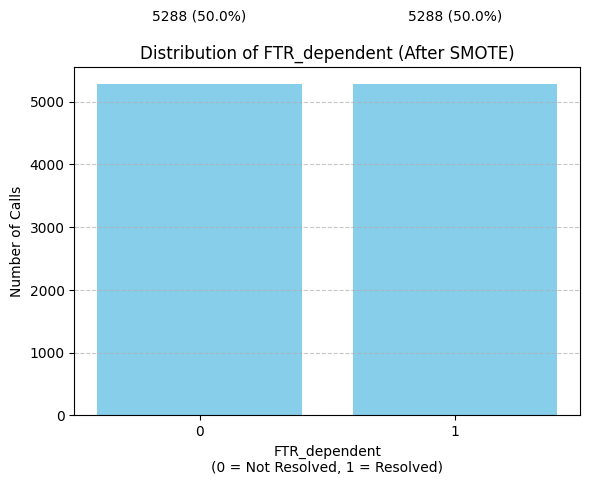

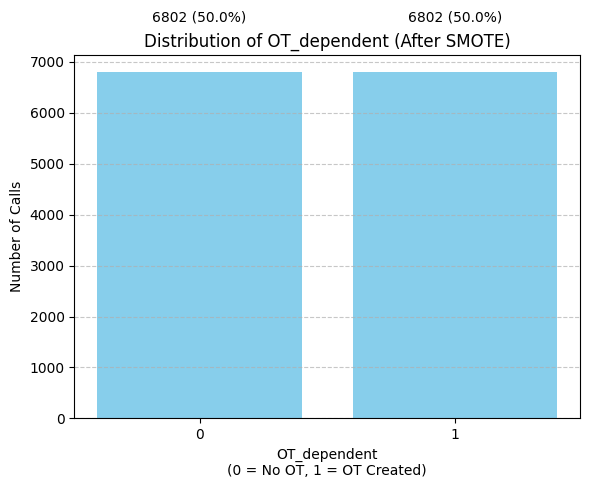

In [30]:
import matplotlib.pyplot as plt
import pandas as pd

# FTR distribution after SMOTE
ftr_after = pd.Series(y_train_ftr_res).value_counts().sort_index()
ftr_after_pct = ftr_after / ftr_after.sum()

plt.figure(figsize=(6, 5))
bars = plt.bar(ftr_after.index, ftr_after.values, color='skyblue')
for bar, val, pct in zip(bars, ftr_after.values, ftr_after_pct.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1000,
             f"{val} ({pct:.1%})", ha='center', fontsize=10)

plt.title("Distribution of FTR_dependent (After SMOTE)")
plt.xlabel("FTR_dependent\n(0 = Not Resolved, 1 = Resolved)")
plt.ylabel("Number of Calls")
plt.xticks([0, 1])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# OT distribution after SMOTE
ot_after = pd.Series(y_train_ot_res).value_counts().sort_index()
ot_after_pct = ot_after / ot_after.sum()

plt.figure(figsize=(6, 5))
bars = plt.bar(ot_after.index, ot_after.values, color='skyblue')
for bar, val, pct in zip(bars, ot_after.values, ot_after_pct.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1000,
             f"{val} ({pct:.1%})", ha='center', fontsize=10)

plt.title("Distribution of OT_dependent (After SMOTE)")
plt.xlabel("OT_dependent\n(0 = No OT, 1 = OT Created)")
plt.ylabel("Number of Calls")
plt.xticks([0, 1])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### 1.2.8. <a id='toc1_2_8_'></a>[Normalize Numerical Variables](#toc0_)

In [31]:
from sklearn.preprocessing import StandardScaler

def scale_and_return_scaler(X_train, X_test, binary_prefixes):
    numeric_cols = X_train.select_dtypes(include=["number"]).columns

    cols_to_scale = [
        col for col in numeric_cols
        if not any(col.startswith(prefix) for prefix in binary_prefixes)
    ]

    scaler = StandardScaler()
    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()

    if cols_to_scale:
        X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
        X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

    return X_train_scaled, X_test_scaled, scaler, cols_to_scale

In [32]:
# Define binary prefixes
binary_prefixes = [
    "call_TOPIC_CLASSIFIC_ENTRY_AT_FT_",
    "PREV_CALL_TOPIC_CLASSIFIC_ENTRY_AT_FT_",
    "LAG1_LVL2_",
    "IS_FIRST_CALL"
]

# --- Scale TMC ---
X_train_scaled_tmc, X_test_scaled_tmc, scaler_tmc, cols_to_scale_tmc = scale_and_return_scaler(
    X_train_tmc, X_test_tmc, binary_prefixes
)

# --- Scale FTR ---
X_train_scaled_ftr, X_test_scaled_ftr, scaler_ftr, cols_to_scale_ftr = scale_and_return_scaler(
    X_train_ftr, X_test_ftr, binary_prefixes
)

# --- Scale OT ---
X_train_scaled_ot, X_test_scaled_ot, scaler_ot, cols_to_scale_ot = scale_and_return_scaler(
    X_train_ot, X_test_ot, binary_prefixes
)

# Optional: Combine if needed
X_scaled = pd.concat([X_train_scaled_tmc, X_test_scaled_tmc])

In [33]:
X_train_scaled_tmc.head()

,call_LEG_IF_ID,gc_COUNT_CALLS,gc_DAYS_ACTIVE,gc_MEAN_FTR,gc_MEAN_TMC,gc_OTS_BY_CALL,gc_COUNT_CALLS_IF,gc_MEAN_FTR_IF,gc_MEAN_TMC_IF,gc_TOTAL_OTS_IF,gc_OTS_BY_CALL_IF,gc_COUNT_CALLS_OTHER,gc_MEAN_FTR_OTHER,gc_MEAN_TMC_OTHER,gc_TOTAL_OTS_OTHER,gc_OTS_BY_CALL_OTHER,gc_COUNT_CALLS_VF,gc_MEAN_FTR_VF,gc_MEAN_TMC_VF,gc_TOTAL_OTS_VF,gc_OTS_BY_CALL_VF,gc_COUNT_CALLS_TV,gc_MEAN_FTR_TV,gc_MEAN_TMC_TV,gc_TOTAL_OTS_TV,gc_OTS_BY_CALL_TV,gc_COUNT_CALLS_MOVEL,gc_MEAN_FTR_MOVEL,gc_MEAN_TMC_MOVEL,gc_TOTAL_OTS_MOVEL,gc_CALLS_IF_BINARY,gc_CALLS_OTHER_BINARY,gc_CALLS_VF_BINARY,gc_CALLS_TV_BINARY,gc_CALLS_MOVEL_BINARY,client_CLIENT_AGE_YEARS,client_CLIENT_ANTIQUITY_YEARS,client_NR_SAS,client_ARPU_CALCULATED,client_ARPU_CLIENT,client_PF_CLIENT_MONTHS,client_LEG_DURATION_MEAN_365_ASSUNTO_IF,client_LEG_DURATION_MEAN_365_ASSUNTO_MOVEL,client_LEG_DURATION_MEAN_365_ASSUNTO_OTHER,client_LEG_DURATION_MEAN_365_ASSUNTO_TV,client_LEG_DURATION_MEAN_365_ASSUNTO_VF,client_LEG_DURATION_MEAN_365_TOTAL,client_RPC_MEAN_365_ASSUNTO_IF,client_RPC_MEAN_365_ASSUNTO_MOVEL,client_RPC_MEAN_365_ASSUNTO_OTHER,client_RPC_MEAN_365_ASSUNTO_TV,client_RPC_MEAN_365_ASSUNTO_VF,client_RPC_MEAN_365_TOTAL,client_FTR_CALCULATED_MEAN_365_ASSUNTO_IF,client_FTR_CALCULATED_MEAN_365_ASSUNTO_MOVEL,client_FTR_CALCULATED_MEAN_365_ASSUNTO_OTHER,client_FTR_CALCULATED_MEAN_365_ASSUNTO_TV,client_FTR_CALCULATED_MEAN_365_ASSUNTO_VF,client_FTR_CALCULATED_MEAN_365_TOTAL,client_NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_IF,client_NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_MOVEL,client_NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_OTHER,client_NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_TV,client_NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_VF,client_NR_INCIDENTS_PER_LEG_SUM_365_TOTAL,client_CALL_IF_ID_NUNIQUE_365_ASSUNTO_IF,client_CALL_IF_ID_NUNIQUE_365_ASSUNTO_MOVEL,client_CALL_IF_ID_NUNIQUE_365_ASSUNTO_OTHER,client_CALL_IF_ID_NUNIQUE_365_ASSUNTO_TV,client_CALL_IF_ID_NUNIQUE_365_ASSUNTO_VF,client_CALL_IF_ID_NUNIQUE_365_TOTAL,client_Age_missing,days_since_prev_call_for_client,client_called_in_last_7_days,days_since_last_call_gc,is_weekend,hour_of_day,IS_FIRST_CALL,CNT_LVL2_ADESÃO/ALTERAÇÃO,CNT_LVL2_BOX,CNT_LVL2_CARTÃO SIM/ESIM/TWIN,CNT_LVL2_INTERNET FIXA,CNT_LVL2_MAIS INFORMAÇÕES,CNT_LVL2_OUTROS,CNT_LVL2_SEM VOZ DE CLIENTE,CNT_LVL2_TELEVISÃO,CNT_LVL2_VOZ FIXA,PROP_LVL2_ADESÃO/ALTERAÇÃO,PROP_LVL2_BOX,PROP_LVL2_CARTÃO SIM/ESIM/TWIN,PROP_LVL2_INTERNET FIXA,PROP_LVL2_MAIS INFORMAÇÕES,PROP_LVL2_OUTROS,PROP_LVL2_SEM VOZ DE CLIENTE,PROP_LVL2_TELEVISÃO,PROP_LVL2_VOZ FIXA,LAG1_LVL2_ADESÃO/ALTERAÇÃO,LAG1_LVL2_BOX,LAG1_LVL2_CARTÃO SIM/ESIM/TWIN,LAG1_LVL2_INTERNET FIXA,LAG1_LVL2_MAIS INFORMAÇÕES,LAG1_LVL2_OUTROS,LAG1_LVL2_SEM VOZ DE CLIENTE,LAG1_LVL2_TELEVISÃO,LAG1_LVL2_VOZ FIXA,avg_duration,call_TOPIC_CLASSIFIC_ENTRY_AT_FT_Móvel,call_TOPIC_CLASSIFIC_ENTRY_AT_FT_OTHER,call_TOPIC_CLASSIFIC_ENTRY_AT_FT_TV,call_TOPIC_CLASSIFIC_ENTRY_AT_FT_VF,PREV_CALL_TOPIC_CLASSIFIC_ENTRY_AT_FT_Móvel,PREV_CALL_TOPIC_CLASSIFIC_ENTRY_AT_FT_OTHER,PREV_CALL_TOPIC_CLASSIFIC_ENTRY_AT_FT_TV,PREV_CALL_TOPIC_CLASSIFIC_ENTRY_AT_FT_VF
34114,0.167708,-0.554444,-0.213383,-0.605655,0.068702,-0.123717,-0.490995,0.050840,-0.039799,-0.337787,0.651153,-0.546919,-0.526411,0.141761,-0.795451,-0.531019,-0.581437,-0.766607,-0.401627,-0.933694,-1.074436,-0.317079,-0.714494,-0.272017,-0.602218,-1.149304,-0.663002,0.017984,0.506654,-0.536452,0.0,0.0,0.047839,0.0,0.0,0.544690,-0.216786,-0.051821,-0.028055,-0.038618,0.950629,-0.416148,-0.119286,-0.4209,-0.342080,-0.13477,-0.703978,-0.414527,-0.122825,-0.526513,-0.356373,-0.152832,-0.78685,0.395304,0.112199,0.245254,0.333605,0.118189,0.623073,-0.383047,-0.111403,-0.215002,-0.335729,-0.135284,-0.365380,-0.414191,-0.115171,-0.205258,-0.351706,-0.149437,-0.343797,-0.445697,-0.229253,0.838053,-0.072021,-0.642817,1.313066,0,-0.145353,2.711953,-0.091855,-0.516415,-0.115825,-0.196879,-0.102638,-0.350064,-0.179574,-0.137564,3.933188,-0.099717,-0.619111,-0.124347,-0.338494,-0.174632,-0.384718,-0.192627,0,1,0,0,0,0,0,0,0,0.605256,False,False,True,False,F

## 1.3. <a id='toc1_3_'></a>[Regression Models to predict TMC](#toc0_)

### 1.3.2. <a id='toc1_3_2_'></a>[TMC: XGBoost Regressor](#toc0_)

In [36]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import shap


# 1. Re-encode categorical variables (if not already done)
# final_df = pd.get_dummies(reduced_df, drop_first=True)

# 2. Save LEG_IF_ID as index if not already
if "LEG_IF_ID" in final_df.columns:
    final_df = final_df.set_index("LEG_IF_ID")

# 3. Define features and target
X = final_df.drop(columns=["TMC_dependent", "FTR_dependent", "OT_dependent"])
y_tmc = final_df["TMC_dependent"]

# 4. Train/Test Split
X_train_tmc, X_test_tmc, y_train_tmc, y_test_tmc = train_test_split(X, y_tmc, test_size=0.2, random_state=42)



In [37]:
# 5. Hyperparameter tuning

# Optional: Baseline for comparison
xgb_base = XGBRegressor(random_state=42)
xgb_base.fit(X_train_tmc, y_train_tmc)

from sklearn.model_selection import GridSearchCV

# Define base estimator and coarse grid
base_xgb = XGBRegressor(random_state=42)
param_grid_coarse = {
    "n_estimators":   [50, 100, 200],
    "max_depth":      [4, 6, 8],
    "learning_rate":  [0.01, 0.1, 0.2],
}

# Run GridSearchCV
grid_coarse = GridSearchCV(
    estimator=base_xgb,
    param_grid=param_grid_coarse,
    scoring="r2",
    cv=3,
    n_jobs=-1,
    verbose=1
)
grid_coarse.fit(X_train_tmc, y_train_tmc)

# Grab the best estimator
print("Coarse best params:", grid_coarse.best_params_)
xgb_tmc = grid_coarse.best_estimator_


Fitting 3 folds for each of 27 candidates, totalling 81 fits
Coarse best params: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 50}


XGBoost Regressor for TMC
R²:   0.1193
MSE:  471875.26
RMSE: 686.93


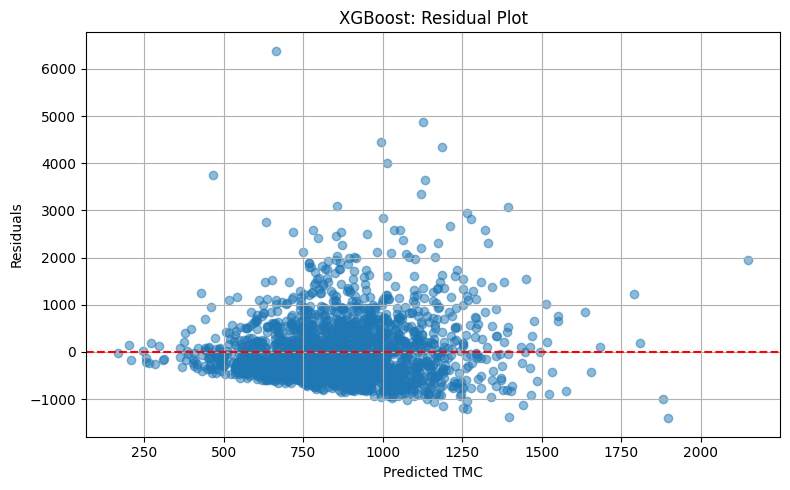

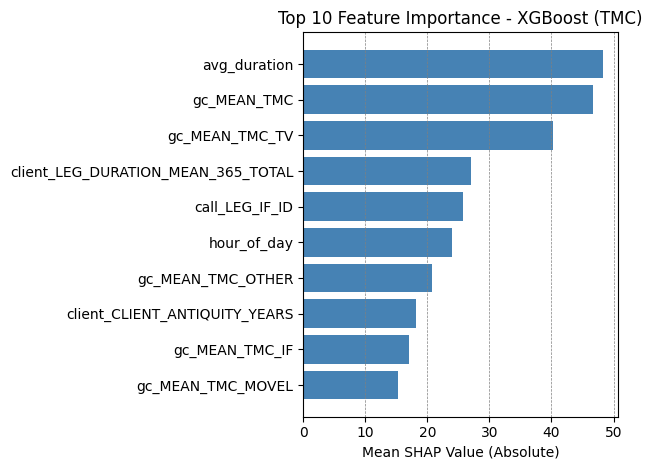


Pairwise Comparison Evaluation:
Pairwise Accuracy: 62.36%


In [90]:
# 6. Predict and evaluate
y_pred_xgb = xgb_tmc.predict(X_test_tmc)
residuals_xgb = y_test_tmc - y_pred_xgb

# Ensure data types are consistent
y_test_tmc = np.array(y_test_tmc)
y_pred_xgb = np.array(y_pred_xgb)

print("XGBoost Regressor for TMC")
print(f"R²:   {r2_score(y_test_tmc, y_pred_xgb):.4f}")

# Manually calculate MSE and RMSE
mse = np.mean((y_test_tmc - y_pred_xgb) ** 2)
rmse = np.sqrt(mse)
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")

# 7. Residual plot
plt.figure(figsize=(8, 5))
plt.scatter(y_pred_xgb, residuals_xgb, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title("XGBoost: Residual Plot")
plt.xlabel("Predicted TMC")
plt.ylabel("Residuals")
plt.grid(True)
plt.tight_layout()
plt.show()

# 8. Feature importances with absolute SHAP values
# Get SHAP values for feature effects
explainer = shap.Explainer(xgb_tmc)
shap_values = explainer(X_train_tmc)

# Mean absolute SHAP values per feature
shap_df = pd.DataFrame({
    'Feature': X_train_tmc.columns,
    'Mean_SHAP': np.mean(np.abs(shap_values.values), axis=0)
})
top10_shap = shap_df.sort_values(by='Mean_SHAP', ascending=False).head(10)

# 9. Plot top 10 feature effects (absolute SHAP values)
plt.figure()
plt.barh(top10_shap['Feature'], top10_shap['Mean_SHAP'], color='steelblue')
plt.grid(axis='x', color='gray', linestyle='--', linewidth=0.5)
plt.xlabel("Mean SHAP Value (Absolute)")
plt.title("Top 10 Feature Importance - XGBoost (TMC)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.grid(True, axis='x')
plt.show()

# 10. Pairwise comparison evaluation
print("\nPairwise Comparison Evaluation:")

# Number of pairs to sample
num_samples = 1000000  # Adjust this based on your system's memory capacity

# Randomly sample pairs of indices
indices = np.random.choice(len(y_test_tmc), size=(num_samples, 2), replace=True)

# Initialize counters for correct comparisons
correct_predictions = 0

# Perform pairwise comparisons
for i, j in indices:
    # Actual values
    actual_i = y_test_tmc[i]
    actual_j = y_test_tmc[j]

    # Predicted values
    pred_i = y_pred_xgb[i]
    pred_j = y_pred_xgb[j]

    # Compare actual and predicted rankings
    if (actual_i > actual_j and pred_i > pred_j) or (actual_i < actual_j and pred_i < pred_j):
        correct_predictions += 1

# Calculate pairwise accuracy
pairwise_accuracy_xgb_tmc = correct_predictions / num_samples
print(f"Pairwise Accuracy: {pairwise_accuracy_xgb_tmc:.2%}")

Importance Gain for additional Information

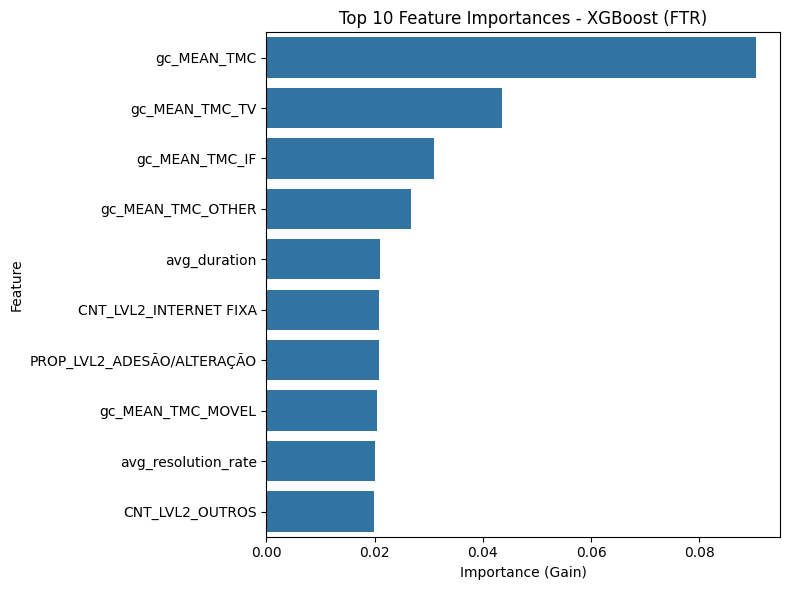

In [75]:
# Feature importance from XGBoost (gain-based by default)
importances = xgb_tmc.feature_importances_
feature_names = X_train_tmc.columns if hasattr(X_train_tmc, "columns") else [f"Feature {i}" for i in range(X_train_tmc.shape[1])]

# Create DataFrame
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Plot top 10 features
plt.figure(figsize=(8, 6))
sns.barplot(data=importance_df.head(10), x="Importance", y="Feature")
ax.grid(axis='x', color='gray', linestyle='--', linewidth=0.5)
plt.title("Top 10 Feature Importances - XGBoost (FTR)")
plt.xlabel("Importance (Gain)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 1.4. <a id='toc1_4_'></a>[Classification Models to predict FTR](#toc0_)

### 1.4.2. <a id='toc1_4_2_'></a>[FTR: XGBoost Classifier](#toc0_)

In [58]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay, precision_score, recall_score
)
import matplotlib.pyplot as plt
import numpy as np
import shap

# Hyperparameter tuning

# Optional baseline for comparison (you can remove this block if you don’t need a baseline)
xgb_base = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_base.fit(X_train_ftr, y_train_ftr)

# ── Grid Search ──
from sklearn.model_selection import GridSearchCV

base_xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
param_grid_coarse = {
    "n_estimators":  [50, 100, 200],
    "max_depth":     [4, 6, 8],
    "learning_rate": [0.01, 0.1, 0.2],
}

grid_coarse = GridSearchCV(
    estimator=base_xgb,
    param_grid=param_grid_coarse,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=1
)
grid_coarse.fit(X_train_ftr, y_train_ftr)

print("Coarse best params:", grid_coarse.best_params_)
xgb_ftr = grid_coarse.best_estimator_


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [12:24:26] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Fitting 3 folds for each of 27 candidates, totalling 81 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [12:24:47] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Coarse best params: {'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 200}


ROC AUC: 0.7185


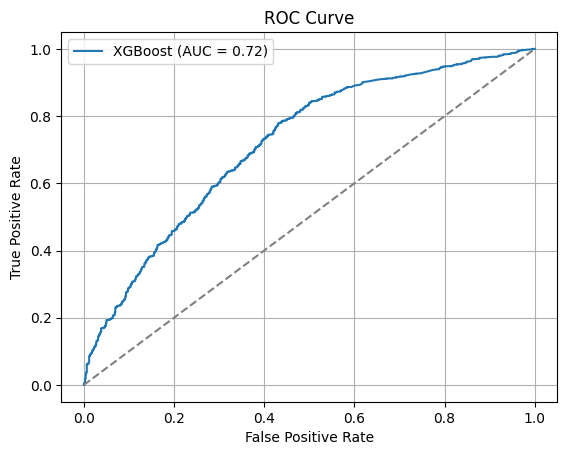

Best Threshold (F1): 0.45
Precision: 0.72, Recall: 0.90, F1: 0.80

Precision (Adjusted Threshold): 0.7175
Recall (Adjusted Threshold): 0.9009
F1 Score (Adjusted Threshold): 0.7988

Classification Report at Adjusted Threshold:
              precision    recall  f1-score   support

           0       0.69      0.38      0.49       759
           1       0.72      0.90      0.80      1322

    accuracy                           0.71      2081
   macro avg       0.70      0.64      0.65      2081
weighted avg       0.71      0.71      0.69      2081



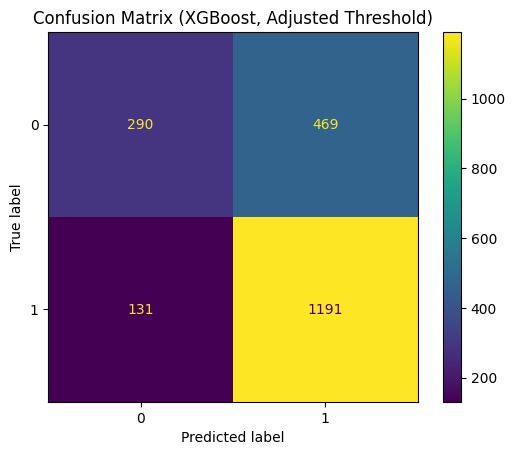

       PRED_PROB_FTR_1  TRUE_FTR
44168         0.756095         1
47421         0.627852         1
33539         0.602749         1
12617         0.829556         1
35991         0.562469         1
37935         0.837534         1
36434         0.674611         1
38228         0.440987         0
38203         0.696423         1
43879         0.698539         1


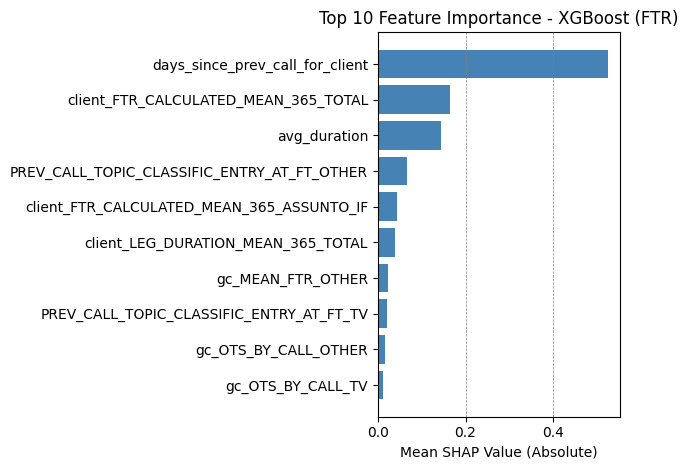


Pairwise Comparison Evaluation:
Pairwise Accuracy: 71.65%


In [89]:
# Evaluation Metrics -----------------------------------------------------------
# Predict probabilities
y_prob_xgb = xgb_ftr.predict_proba(X_test_ftr)[:, 1]

# ROC AUC
roc_auc = roc_auc_score(y_test_ftr, y_prob_xgb)
print(f"ROC AUC: {roc_auc:.4f}")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test_ftr, y_prob_xgb)
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

# Find best threshold using F1
precisions, recalls, thresholds = precision_recall_curve(y_test_ftr, y_prob_xgb)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]

print(f"Best Threshold (F1): {best_thresh:.2f}")
print(f"Precision: {precisions[best_idx]:.2f}, Recall: {recalls[best_idx]:.2f}, F1: {f1_scores[best_idx]:.2f}")

# Apply threshold
y_pred_thresh = (y_prob_xgb >= best_thresh).astype(int)

# Evaluation
precision = precision_score(y_test_ftr, y_pred_thresh)
recall = recall_score(y_test_ftr, y_pred_thresh)
f1 = f1_score(y_test_ftr, y_pred_thresh)

print(f"\nPrecision (Adjusted Threshold): {precision:.4f}")
print(f"Recall (Adjusted Threshold): {recall:.4f}")
print(f"F1 Score (Adjusted Threshold): {f1:.4f}")

print("\nClassification Report at Adjusted Threshold:")
print(classification_report(y_test_ftr, y_pred_thresh))
ConfusionMatrixDisplay(confusion_matrix(y_test_ftr, y_pred_thresh)).plot()
plt.title("Confusion Matrix (XGBoost, Adjusted Threshold)")
plt.show()

# Show predicted probabilities and actuals
pred_df = X_test_ftr.copy()
pred_df['PRED_PROB_FTR_1'] = y_prob_xgb
pred_df['TRUE_FTR'] = y_test_ftr
print(pred_df[['PRED_PROB_FTR_1', 'TRUE_FTR']].head(10))

## Feature Importance (SHAP)----------------------------------------------------
# Get SHAP values for feature effects
explainer = shap.Explainer(xgb_ftr)
shap_values = explainer(X_train_ftr)

# Mean absolute SHAP values per feature
shap_df = pd.DataFrame({
    'Feature': X_train_ftr.columns,
    'Mean_SHAP': np.mean(np.abs(shap_values.values), axis=0)
})
top10_shap = shap_df.sort_values(by='Mean_SHAP', ascending=False).head(10)

# 9. Plot top 10 feature effects (absolute SHAP values)
plt.figure()
plt.barh(top10_shap['Feature'], top10_shap['Mean_SHAP'], color='steelblue')
plt.grid(axis='x', color='gray', linestyle='--', linewidth=0.5)
plt.xlabel("Mean SHAP Value (Absolute)")
plt.title("Top 10 Feature Importance - XGBoost (FTR)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.grid(True, axis='x')
plt.show()

## Pairwise Comparison ---------------------------------------------------------
# Pairwise comparison evaluation for binary classification
print("\nPairwise Comparison Evaluation:")

# Ensure data types are consistent
y_test_ftr = np.array(y_test_ftr)
y_prob_xgb = np.array(y_prob_xgb)

# Number of pairs to sample
num_samples = 1000000  # Adjust this based on your system's memory capacity

# Randomly sample pairs of indices
indices = np.random.choice(len(y_test_ftr), size=(num_samples, 2), replace=True)

# Initialize counters for correct comparisons
correct_predictions = 0
valid_pairs = 0  # Count valid pairs (where actual_i != actual_j)

# Perform pairwise comparisons
for i, j in indices:
    # Actual values
    actual_i = y_test_ftr[i]
    actual_j = y_test_ftr[j]

    # Predicted probabilities
    prob_i = y_prob_xgb[i]
    prob_j = y_prob_xgb[j]

    # Skip pairs where both actual labels are the same
    if actual_i == actual_j:
        continue

    # Compare actual and predicted rankings
    valid_pairs += 1
    if (actual_i > actual_j and prob_i > prob_j) or (actual_i < actual_j and prob_i < prob_j):
        correct_predictions += 1

# Calculate pairwise accuracy
if valid_pairs > 0:
    pairwise_accuracy_xgb_ftr = correct_predictions / valid_pairs
    print(f"Pairwise Accuracy: {pairwise_accuracy_xgb_ftr:.2%}")
else:
    print("No valid pairs for pairwise comparison.")

Importance Gain for additional information

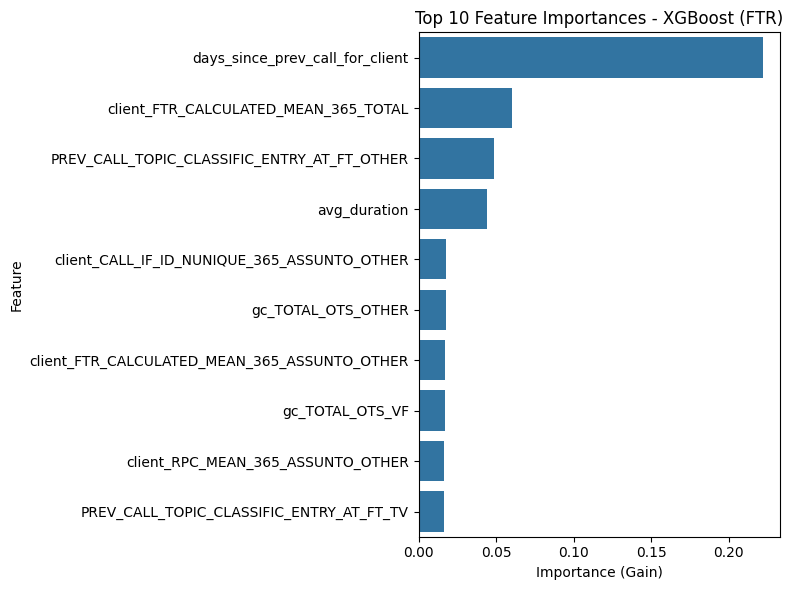

In [73]:
# Feature importance from XGBoost (gain-based by default)
importances = xgb_ftr.feature_importances_
feature_names = X_train_ftr.columns if hasattr(X_train_ftr, "columns") else [f"Feature {i}" for i in range(X_train_ftr.shape[1])]

# Create DataFrame
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Plot top 10 features
plt.figure(figsize=(8, 6))
sns.barplot(data=importance_df.head(10), x="Importance", y="Feature")
ax.grid(axis='x', color='gray', linestyle='--', linewidth=0.5)
plt.title("Top 10 Feature Importances - XGBoost (FTR)")
plt.xlabel("Importance (Gain)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 1.5. <a id='toc1_5_'></a>[Classification Models to predict OT](#toc0_)

### 1.5.2. <a id='toc1_5_2_'></a>[OT: XGBoost Classifier](#toc0_)

Fitting 3 folds for each of 27 candidates, totalling 81 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:42:09] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Best Parameters: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100}
ROC AUC: 0.6515


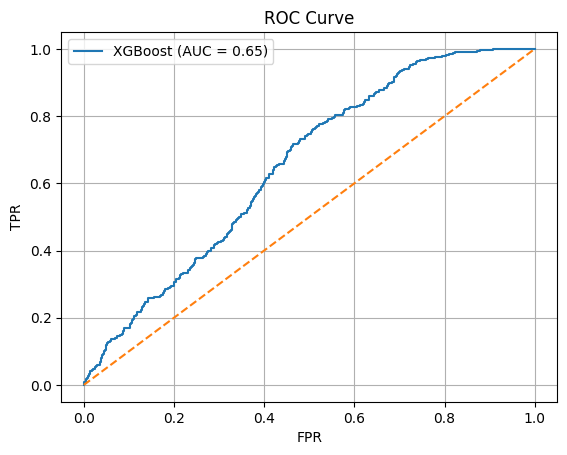

Best Threshold (F1): 0.19
Precision: 0.25, Recall: 0.73, F1: 0.38

Precision (Adjusted Threshold): 0.2546
Recall    (Adjusted Threshold): 0.7316
F1 Score  (Adjusted Threshold): 0.3777
Classification Report at Adjusted Threshold:
              precision    recall  f1-score   support

           0       0.90      0.52      0.66      1701
           1       0.25      0.73      0.38       380

    accuracy                           0.56      2081
   macro avg       0.58      0.63      0.52      2081
weighted avg       0.78      0.56      0.61      2081



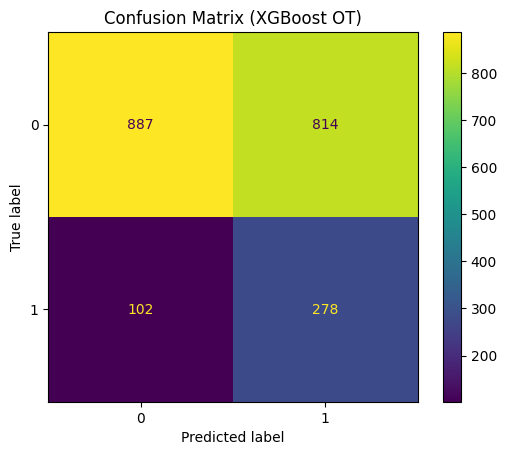

       PRED_PROB_OT_1  TRUE_OT
24014        0.200915        0
32250        0.167424        0
50680        0.269787        0
29176        0.213948        0
49699        0.273953        0
49240        0.243188        1
36688        0.183022        0
28305        0.397613        0
47019        0.240385        0
27000        0.263745        0


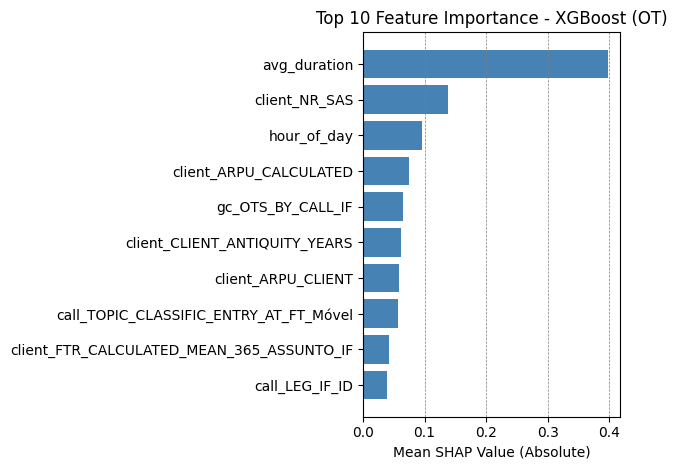


Pairwise Comparison Evaluation:
Pairwise Accuracy: 65.18%


In [115]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score
)
import matplotlib.pyplot as plt
import numpy as np
import shap

# === Hyperparameter tuning: Grid Search ===
param_grid = {
    "n_estimators":  [50, 100, 200],
    "max_depth":     [4, 6, 8],
    "learning_rate": [0.01, 0.1, 0.2],
}

grid_search = GridSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric='logloss', n_jobs=-1, random_state=42),
    param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=1
)

# fit all candidates and select the best
grid_search.fit(X_train_ot, y_train_ot)
xgb_ot = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

## Evaluation ------------------------------------------------------------------
# === Predict probabilities ===
y_prob_xgb = xgb_ot.predict_proba(X_test_ot)[:, 1]

# ROC AUC
roc_auc = roc_auc_score(y_test_ot, y_prob_xgb)
print(f"ROC AUC: {roc_auc:.4f}")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test_ot, y_prob_xgb)
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

# Optimal threshold
precisions, recalls, thresholds = precision_recall_curve(y_test_ot, y_prob_xgb)
f1s = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1s)
best_thresh = thresholds[best_idx]
print(f"Best Threshold (F1): {best_thresh:.2f}")
print(f"Precision: {precisions[best_idx]:.2f}, Recall: {recalls[best_idx]:.2f}, F1: {f1s[best_idx]:.2f}")

# Predictions
y_pred = (y_prob_xgb >= best_thresh).astype(int)

# Precision, Recall, and F1 Score at the adjusted threshold
precision = precision_score(y_test_ot, y_pred)
recall    = recall_score(y_test_ot, y_pred)
f1        = f1_score(y_test_ot, y_pred)
print(f"\nPrecision (Adjusted Threshold): {precision:.4f}")
print(f"Recall    (Adjusted Threshold): {recall:.4f}")
print(f"F1 Score  (Adjusted Threshold): {f1:.4f}")

# Classification Report and Confusion Matrix
print("Classification Report at Adjusted Threshold:")
print(classification_report(y_test_ot, y_pred))
ConfusionMatrixDisplay(confusion_matrix(y_test_ot, y_pred)).plot()
plt.title("Confusion Matrix (XGBoost OT)")
plt.show()

# Table
pred_df = X_test_ot.copy()
pred_df["PRED_PROB_OT_1"] = y_prob_xgb
pred_df["TRUE_OT"]        = y_test_ot
print(pred_df[["PRED_PROB_OT_1", "TRUE_OT"]].head(10))

## Feature Importance (SHAP)----------------------------------------------------
# Get SHAP values for feature effects
explainer = shap.Explainer(xgb_ot)
shap_values = explainer(X_train_ot)

# Mean absolute SHAP values per feature
shap_df = pd.DataFrame({
    'Feature': X_train_ot.columns,
    'Mean_SHAP': np.mean(np.abs(shap_values.values), axis=0)
})
top10_shap = shap_df.sort_values(by='Mean_SHAP', ascending=False).head(10)

# Plot top 10 feature effects (absolute SHAP values)
plt.figure()
plt.barh(top10_shap['Feature'], top10_shap['Mean_SHAP'], color='steelblue')
plt.grid(axis='x', color='gray', linestyle='--', linewidth=0.5)
plt.xlabel("Mean SHAP Value (Absolute)")
plt.title("Top 10 Feature Importance - XGBoost (OT)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.grid(True, axis='x')
plt.show()

## Pairwise Comparison----------------------------------------------------------
# Pairwise comparison evaluation for binary classification
print("\nPairwise Comparison Evaluation:")

# Ensure data types are consistent
y_test_ot   = np.array(y_test_ot)
y_prob_xgb  = np.array(y_prob_xgb)

# Number of pairs to sample
num_samples = 1000000  # Adjust this based on your system's memory capacity

# Randomly sample pairs of indices
indices = np.random.choice(len(y_test_ot), size=(num_samples, 2), replace=True)

# Initialize counters for correct comparisons
correct_predictions = 0
valid_pairs         = 0  # Count valid pairs (where actual_i != actual_j)

# Perform pairwise comparisons
for i, j in indices:
    # Actual values
    actual_i = y_test_ot[i]
    actual_j = y_test_ot[j]

    # Predicted probabilities
    prob_i = y_prob_xgb[i]
    prob_j = y_prob_xgb[j]

    # Skip pairs where both actual labels are the same
    if actual_i == actual_j:
        continue

    # Compare actual and predicted rankings
    valid_pairs += 1
    if (actual_i > actual_j and prob_i > prob_j) or (actual_i < actual_j and prob_i < prob_j):
        correct_predictions += 1

# Calculate pairwise accuracy
if valid_pairs > 0:
    pairwise_accuracy_xgb_ot = correct_predictions / valid_pairs
    print(f"Pairwise Accuracy: {pairwise_accuracy_xgb_ot:.2%}")
else:
    print("No valid pairs for pairwise comparison.")



Feature Importance: Information Gain

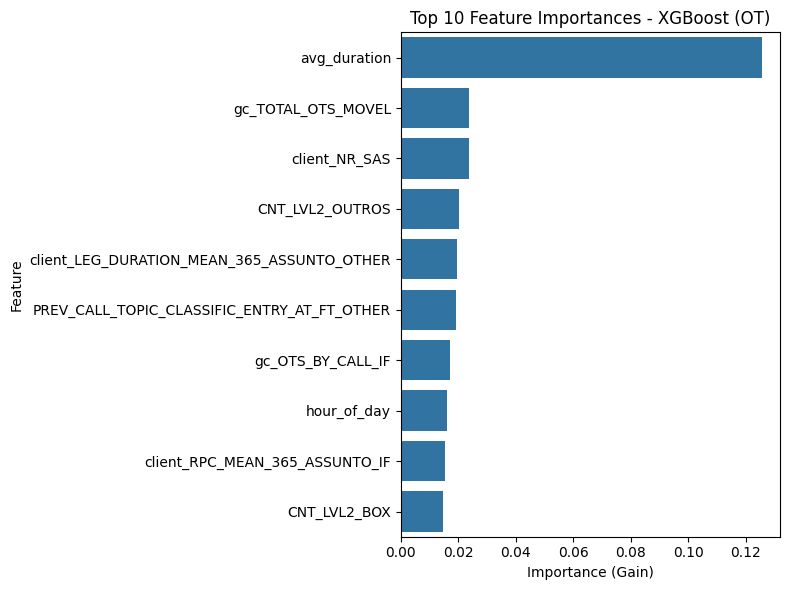

In [86]:
# XGBoost feature importances (default: gain-based)
feature_names = X_train_ot.columns if hasattr(X_train_ot, "columns") else [f"Feature {i}" for i in range(X_train_ot.shape[1])]
importances = xgb_ot.feature_importances_

# Create DataFrame
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Plot top 10 features
plt.figure(figsize=(8, 6))
sns.barplot(data=importance_df.head(10), x="Importance", y="Feature")
ax.grid(axis='x', color='gray', linestyle='--', linewidth=0.5)
plt.title("Top 10 Feature Importances - XGBoost (OT)")
plt.xlabel("Importance (Gain)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 1.6. <a id='toc1_6_'></a>[Apply on sample calls and select suitable GC](#toc0_)

### 1.6.1. <a id='toc1_6_1_'></a>[Create GCs Unique Table](#toc0_)

In [95]:
gc_columns = [col for col in final_df.columns if col.startswith('MEAN_') or col.startswith('TOTAL_') or col.startswith('COUNT_') or col.startswith('OTS_') or col.startswith('CALLS_')]
#gc_columns += ['ARPU_CLIENT', 'CLIENT_AGE_YEARS', 'N_PAST_CALLS']  # Add if you want these

gcs_unique = full_merged_df[['RESOURCE_KEY'] + gc_columns].drop_duplicates(subset='RESOURCE_KEY').set_index('RESOURCE_KEY')
gcs_unique.head()

""
RESOURCE_KEY
11741170013
11741920010
11750000013
11763970008
11776310014


### 1.6.2. <a id='toc1_6_2_'></a>[Define 10 Sample Calls](#toc0_)

In [96]:
import numpy as np
import pandas as pd

# Select 10 random calls
sample_calls = final_df.sample(n=10, random_state=42)
sample_ids = sample_calls.index.tolist()
sample_data = X.loc[sample_ids]

### 1.6.4. <a id='toc1_6_4_'></a>[BOOSTED (XG Boost Regressor and Classifier)](#toc0_)

In [99]:
from xgboost import XGBRegressor, XGBClassifier

# Regression model for TMC
xgb_reg = XGBRegressor(random_state=42)
xgb_reg.fit(X_train_scaled_tmc, y_train_tmc)

# Classification model for FTR
xgb_clf_ftr = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_clf_ftr.fit(X_train_scaled_ftr, y_train_ftr)

# Classification model for OT
xgb_clf_ot = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_clf_ot.fit(X_train_scaled_ot, y_train_ot)



/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:24:04] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:24:06] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [100]:
from typing import Sequence

def simulate_boosted_calls(
    sample_ids: Sequence,
    final_df: pd.DataFrame,
    gcs_unique: pd.DataFrame,
    xgb_reg,
    xgb_clf_ftr,
    xgb_clf_ot,
    scaler_tmc,
    scaler_ftr,
    scaler_ot,
    feature_tmc: Sequence[str],
    feature_ftr: Sequence[str],
    feature_ot: Sequence[str],
    cols_to_scale_tmc: Sequence[str],
    cols_to_scale_ftr: Sequence[str],
    cols_to_scale_ot: Sequence[str]
) -> pd.DataFrame:
    all_predictions = []

    for call_id in sample_ids:
        # pull the call, drop the dependent columns and any GC cols
        call_row = final_df.loc[call_id].drop(
            ["TMC_dependent", "FTR_dependent", "OT_dependent"] +
            [c for c in gcs_unique.columns if c in final_df.columns]
        )

        for gc_id, gc_row in gcs_unique.iterrows():
            # 1) build the raw feature vector
            combined = pd.concat([call_row, gc_row])

            # 2) make three one-row DataFrames in the right column order
            x_tmc = combined.reindex(feature_tmc).to_frame().T
            x_ftr = combined.reindex(feature_ftr).to_frame().T
            x_ot  = combined.reindex(feature_ot).to_frame().T

            # ==== SCALING STEPS ====
            # TMC
            sub_tmc = x_tmc[cols_to_scale_tmc].values.reshape(1, -1)
            scaled_tmc = scaler_tmc.transform(sub_tmc)
            x_tmc.loc[:, cols_to_scale_tmc] = scaled_tmc
            row_tmc = x_tmc.values  # now in the exact feature order

            # FTR
            sub_ftr = x_ftr[cols_to_scale_ftr].values.reshape(1, -1)
            scaled_ftr = scaler_ftr.transform(sub_ftr)
            x_ftr.loc[:, cols_to_scale_ftr] = scaled_ftr
            row_ftr = x_ftr.values

            # OT
            sub_ot = x_ot[cols_to_scale_ot].values.reshape(1, -1)
            scaled_ot = scaler_ot.transform(sub_ot)
            x_ot.loc[:, cols_to_scale_ot] = scaled_ot
            row_ot = x_ot.values
            # ==== END PATCH ====

            # 3) predictions
            pred_tmc = xgb_reg.predict(row_tmc)[0]
            p_ftr    = xgb_clf_ftr.predict_proba(row_ftr)[0][1]
            p_ot     = xgb_clf_ot.predict_proba(row_ot)[0][1]

            #average duration for the client
            avg_client_duration = combined["client_LEG_DURATION_MEAN_365_TOTAL"]

            # cost calculation
            call_cost   = pred_tmc / 60 * 0.35
            tech_cost   = p_ot * 22
            repeat_cost = (1 - p_ftr) * (avg_client_duration/ 60 * 0.35)
            total_cost  = call_cost + tech_cost + repeat_cost


            all_predictions.append({
                "Model":        "BOOSTED",
                "LEG_IF_ID":    call_id,
                "RESOURCE_KEY": gc_id,
                "Pred_TMC":     pred_tmc,
                "P_FTR":        p_ftr,
                "P_OT":         p_ot,
                "Total_Cost":   total_cost
            })

    return pd.DataFrame(all_predictions)


In [101]:
boosted_results = simulate_boosted_calls(
    sample_ids        = sample_ids,
    final_df          = final_df,
    gcs_unique        = gcs_unique,
    xgb_reg           = xgb_reg,
    xgb_clf_ftr       = xgb_clf_ftr,
    xgb_clf_ot        = xgb_clf_ot,
    scaler_tmc        = scaler_tmc,
    scaler_ftr        = scaler_ftr,
    scaler_ot         = scaler_ot,
    feature_tmc       = X_train_scaled_tmc.columns,
    feature_ftr       = X_train_scaled_ftr.columns,
    feature_ot        = X_train_scaled_ot.columns,
    cols_to_scale_tmc = cols_to_scale_tmc,
    cols_to_scale_ftr = cols_to_scale_ftr,
    cols_to_scale_ot  = cols_to_scale_ot
)


Output streaming troncato alle ultime 5000 righe.
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [102]:
boosted_df = pd.DataFrame(boosted_results)

for leg_id in sample_ids:
    print(f"\nTop 10 GCs for Call {leg_id} (BOOSTED):")
    display(boosted_df[boosted_df["LEG_IF_ID"] == leg_id].sort_values("Total_Cost").head(10))



Top 10 GCs for Call 45635 (BOOSTED):


,Model,LEG_IF_ID,RESOURCE_KEY,Pred_TMC,P_FTR,P_OT,Total_Cost
376,BOOSTED,45635,14438130001,1012.817078,0.134809,0.023291,6.420512
377,BOOSTED,45635,14441190001,1012.817078,0.134809,0.023291,6.420512
378,BOOSTED,45635,14442230001,1012.817078,0.134809,0.023291,6.420512
379,BOOSTED,45635,14459810001,1012.817078,0.134809,0.023291,6.420512
380,BOOSTED,45635,14459830001,1012.817078,0.134809,0.023291,6.420512
381,BOOSTED,45635,14460160001,1012.817078,0.134809,0.023291,6.420512
382,BOOSTED,45635,14460190001,1012.817078,0.134809,0.023291,6.420512
383,BOOSTED,45635,14460210001,1012.817078,0.134809,0.023291,6.420512
368,BOOSTED,45635,14438020001,1012.817078,0.134809,0.023291,6.420512
369,BOOSTED,45635,14438030001,1012.817078,0.134809,0.023291,6.420512



Top 10 GCs for Call 43892 (BOOSTED):


,Model,LEG_IF_ID,RESOURCE_KEY,Pred_TMC,P_FTR,P_OT,Total_Cost
770,BOOSTED,43892,14438130001,869.138428,0.903011,0.009322,5.523986
771,BOOSTED,43892,14441190001,869.138428,0.903011,0.009322,5.523986
772,BOOSTED,43892,14442230001,869.138428,0.903011,0.009322,5.523986
773,BOOSTED,43892,14459810001,869.138428,0.903011,0.009322,5.523986
774,BOOSTED,43892,14459830001,869.138428,0.903011,0.009322,5.523986
775,BOOSTED,43892,14460160001,869.138428,0.903011,0.009322,5.523986
776,BOOSTED,43892,14460190001,869.138428,0.903011,0.009322,5.523986
777,BOOSTED,43892,14460210001,869.138428,0.903011,0.009322,5.523986
762,BOOSTED,43892,14438020001,869.138428,0.903011,0.009322,5.523986
763,BOOSTED,43892,14438030001,869.138428,0.903011,0.009322,5.523986



Top 10 GCs for Call 25708 (BOOSTED):


...

,Model,LEG_IF_ID,RESOURCE_KEY,Pred_TMC,P_FTR,P_OT,Total_Cost
3134,BOOSTED,36773,14438130001,885.632446,0.501046,0.437189,14.784345
3135,BOOSTED,36773,14441190001,885.632446,0.501046,0.437189,14.784345
3136,BOOSTED,36773,14442230001,885.632446,0.501046,0.437189,14.784345
3137,BOOSTED,36773,14459810001,885.632446,0.501046,0.437189,14.784345
3138,BOOSTED,36773,14459830001,885.632446,0.501046,0.437189,14.784345
3139,BOOSTED,36773,14460160001,885.632446,0.501046,0.437189,14.784345
3140,BOOSTED,36773,14460190001,885.632446,0.501046,0.437189,14.784345
3141,BOOSTED,36773,14460210001,885.632446,0.501046,0.437189,14.784345
3126,BOOSTED,36773,14438020001,885.632446,0.501046,0.437189,14.784345
3127,BOOSTED,36773,14438030001,885.632446,0.501046,0.437189,14.784345



Top 10 GCs for Call 22991 (BOOSTED):


,Model,LEG_IF_ID,RESOURCE_KEY,Pred_TMC,P_FTR,P_OT,Total_Cost
3528,BOOSTED,22991,14438130001,862.070923,0.146742,0.151503,8.361805
3529,BOOSTED,22991,14441190001,862.070923,0.146742,0.151503,8.361805
3530,BOOSTED,22991,14442230001,862.070923,0.146742,0.151503,8.361805
3531,BOOSTED,22991,14459810001,862.070923,0.146742,0.151503,8.361805
3532,BOOSTED,22991,14459830001,862.070923,0.146742,0.151503,8.361805
3533,BOOSTED,22991,14460160001,862.070923,0.146742,0.151503,8.361805
3534,BOOSTED,22991,14460190001,862.070923,0.146742,0.151503,8.361805
3535,BOOSTED,22991,14460210001,862.070923,0.146742,0.151503,8.361805
3520,BOOSTED,22991,14438020001,862.070923,0.146742,0.151503,8.361805
3521,BOOSTED,22991,14438030001,862.070923,0.146742,0.151503,8.361805



Top 10 GCs for Call 30303 (BOOSTED):


,Model,LEG_IF_ID,RESOURCE_KEY,Pred_TMC,P_FTR,P_OT,Total_Cost
3922,BOOSTED,30303,14438130001,272.623627,0.700459,0.012953,1.875266
3923,BOOSTED,30303,14441190001,272.623627,0.700459,0.012953,1.875266
3924,BOOSTED,30303,14442230001,272.623627,0.700459,0.012953,1.875266
3925,BOOSTED,30303,14459810001,272.623627,0.700459,0.012953,1.875266
3926,BOOSTED,30303,14459830001,272.623627,0.700459,0.012953,1.875266
3927,BOOSTED,30303,14460160001,272.623627,0.700459,0.012953,1.875266
3928,BOOSTED,30303,14460190001,272.623627,0.700459,0.012953,1.875266
3929,BOOSTED,30303,14460210001,272.623627,0.700459,0.012953,1.875266
3914,BOOSTED,30303,14438020001,272.623627,0.700459,0.012953,1.875266
3915,BOOSTED,30303,14438030001,272.623627,0.700459,0.012953,1.875266
